In [1]:
import numpy as np
import xarray as xr
import os

from scipy.stats import linregress

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

%matplotlib inline

In [ ]:
# -------------------------------------------------------------------------
# SST–AMOC Regression and Reconstruction Analysis
#
# This notebook performs the following:
#
# 1. Computes SST-AMOC regression patterns for each individual model 
#    and for the multi-model ensemble.
#
# 2. Reconstructs AMOC time series for each model using:
#    - Regression patterns from all other individual models
#    - The multi-model regression pattern
#
# 3. Visualizes:
#    - Reconstructed AMOC vs. true AMOC for each model
#    - Different approaches to computing the multi-model regression
# -------------------------------------------------------------------------

In [2]:
scenario = 'piControl'
running_mean_window = 20

PATH_SST = '/glade/campaign/cgd/oce/people/rita/CMIP6/tos/' + scenario + '/'
PATH_AMOC = '/glade/campaign/cgd/oce/people/rita/CMIP6/Terhaar_etal_2025/Linus_2023_06_14/amoc/26.5N/' + scenario + '/'
PATH_saved_regressions = '/glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/'
PATH_saved_cross_regressions = '/glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_cross_regressions_for_every_model/'

model_names = ['ACCESS-CM2', 'ACCESS-ESM1-5', 'CESM2-WACCM', 'CESM2', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1-HR',
               'CNRM-CM6-1', 'CNRM-ESM2-1', 'CanESM5-CanOE', 'CanESM5', 'GFDL-CM4', 'GFDL-ESM4', 'GISS-E2-1-G', 
               'HadGEM3-GC31-LL', 'HadGEM3-GC31-MM', 'IPSL-CM6A-LR', 'MIROC6', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 
               'MRI-ESM2-0', 'NorESM2-LM', 'NorESM2-MM', 'UKESM1-0-LL']


amoc_institution_names = ['CSIRO-ARCCSS', 'CSIRO', 'NCAR', 'NCAR', 'CMCC', 'CMCC', 'CNRM-CERFACS', 
                         'CNRM-CERFACS', 'CNRM-CERFACS', 'CCCma', 'CCCma', 'NOAA-GFDL', 'NOAA-GFDL', 'NASA-GISS', 
                         'MOHC', 'MOHC', 'IPSL', 'MIROC', 'DKRZ', 'MPI-M', 
                         'MRI', 'NCC', 'NCC', 'MOHC']
                         


ens_members_appendices  = ['r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f2', 
                           'r1i1p1f2', 'r1i1p1f2', 'r1i1p2f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f2', 
                           'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 
                           'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f2']

In [29]:
def prepare_and_normalize_sst(sst):
    """
    Prepare SST by subsetting to North Atlantic, filling NaNs, stacking spatial points, and normalizing.
    """
    sst_selected = sst.fillna(0).stack(spatial=("lat", "lon")).values

    # Normalize SST per spatial point
    sst_mean = np.mean(sst_selected, axis=0)
    sst_std = np.std(sst_selected, axis=0)
    sst_std[sst_std == 0] = 1  # Avoid division by zero
    return (sst_selected - sst_mean) / sst_std


def prepare_and_normalize_amoc(amoc):
    """
    Prepare AMOC by subsetting, filling NaNs, and normalizing.
    """
    amoc_selected = amoc.fillna(0).values
    amoc_mean = np.mean(amoc_selected)
    amoc_std = np.std(amoc_selected)
    return amoc_selected, (amoc_selected - amoc_mean) / amoc_std, amoc_mean, amoc_std

def train_regression_and_reconstruct(sst_normalized, amoc, amoc_std):
    """
    Train regression (compute f) and reconstruct AMOC using SST.
    """
    f = sst_normalized.T @ amoc / sst_normalized.shape[0]
    amoc_reconstructed = sst_normalized @ f
    amoc_reconstructed = amoc_reconstructed * amoc_std / np.std(amoc_reconstructed)  # Rescale
    return f, amoc_reconstructed

def save_regression_map_sst_amoc_to_file(f, ny, nx, years, sst_for_coords, sst_norm, amoc_norm, amoc_std, amoc_recon, model_name, path_output, smoothing_period = 20):
    """
    Saves regression map to file, including:
    - fr (masked regression coefficients)
    - normalized SST (same shape as fr)
    - AMOC time series (1D, yearly values)
    """

    # Reshape `f` to (ny, nx) and mask land areas (0 → NaN)
    fr = np.reshape(f, [ny, nx])
    fr_masked = np.where(fr == 0, np.nan, fr)

    # Extract coordinates
    lat = sst_for_coords["lat"]  # (j, i)
    lon = sst_for_coords["lon"]  # (j, i)

    # Create DataArray for `fr`
    fr_dataarray = xr.DataArray(
        fr_masked, 
        coords={"lat": lat, "lon": lon}, 
        dims=["lat", "lon"], 
        name="fr"
    )

    # === Normalized SST  ===

    sst_masked = np.where(sst_norm == 0, np.nan, sst_norm)

    sst_reshaped = sst_masked.reshape(len(years), ny, nx)
        
    sst_dataarray = xr.DataArray(
        sst_reshaped,
        # coords={"year": np.arange(1 + smoothing_period/2, 251 - smoothing_period/2 + 1), "lat": lat, "lon": lon},
        coords={"year": years, "lat": lat, "lon": lon},
        dims=["year", "lat", "lon"],
        name="sst_normalized"
    )

    # === AMOC Time Series (Yearly Data from period_start to period_end) ===
    # years = np.arange(1 + smoothing_period/2, 251 - smoothing_period/2 + 1)
    assert len(amoc_norm) == len(years), "AMOC (normalised) time series length mismatch!"

    amoc_norm_dataarray = xr.DataArray(
        amoc_norm, 
        coords={"year": years}, 
        dims=["year"], 
        name="amoc"
    )

    amoc_std_dataarray = xr.DataArray(
        amoc_std, 
        name="amoc"
    )

    assert len(amoc_recon) == len(years), "AMOC (reconstructed) time series length mismatch!"

    amoc_recon_dataarray = xr.DataArray(
        amoc_recon, 
        coords={"year": years}, 
        dims=["year"], 
        name="amoc"
    )
    
    # === Merge into a dataset and save ===
    dataset = xr.Dataset({"fr": fr_dataarray, "normalized_sst": sst_dataarray, "amoc_normalised": amoc_norm_dataarray, "amoc_std": amoc_std_dataarray, "amoc_reconstructed": amoc_recon_dataarray})

    # Define output filename
    output_filename = f"{model_name}_{len(years)}yrs.nc"

    # Save to NetCDF
    dataset.to_netcdf(path_output + output_filename)
    print(f"Saved to {path_output + output_filename}")


def plot_regression_coefficients(f, ny, nx, title):
    """
    Reshape and plot regression coefficients with land masked as NaN.
    """
    fr = np.reshape(f, [ny, nx])
    fr_masked = np.where(fr == 0, np.nan, fr)
    plt.figure(figsize=(8, 6))

    if model_names[0]=='MPI-ESM1-2-HR':
        fr_masked = np.flipud(fr_masked)
        
    plt.contourf(fr_masked, cmap="viridis", levels=20)
    plt.colorbar(label="Regression Coefficients")
    plt.title(title)
    plt.show()

def plot_amoc_comparison(amoc_original, amoc_reconstructed, years, title, smoothing_period = 20):
    """
    Plot original vs reconstructed AMOC.
    """
    # years = np.arange(1 + smoothing_period/2, 251 - smoothing_period/2 + 1)
    amoc_original_da = xr.DataArray(amoc_original, dims='year', coords={'year': years})
    amoc_reconstructed_da = xr.DataArray(amoc_reconstructed, dims='year', coords={'year': years})
    
    plt.figure(figsize=(8, 5))
    amoc_original_da.plot(label="Original AMOC", linewidth=2)
    amoc_reconstructed_da.plot(label="Reconstructed AMOC", linestyle="--", linewidth=2)
    plt.title(title)
    plt.xlabel("Year")
    plt.ylabel("AMOC [Sv]")
    plt.legend()
    plt.show()

# Compute SST-based AMOC reconstructions for each individual model 

In [8]:
# for i, model in enumerate(model_names):
#     filename_amoc = PATH_AMOC + 'amoc_' + scenario + '_' + amoc_institution_names[i] + '_' + model + '_' + ens_members_appendices[i] + '.nc'
#     filename_sst = PATH_SST + 'tos_Omon_' + model + '_' + scenario + '_' + ens_members_appendices[i] + '.nc'
#     if os.path.exists(filename_amoc) and os.path.exists(filename_sst):

#         print(model)
        
#         sst_time_series = xr.open_dataset(filename_sst)['tos'].sel(lat = slice(lat_min, lat_max), lon = slice(lon_min, lon_max))
#         sst_time_series['year'] = xr.DataArray(np.arange(1, len(sst_time_series['year'].values)+1), dims = 'year')
#         sst_mean = sst_time_series.mean('year')
#         sst_smoothed = (sst_time_series - sst_mean).rolling(year=running_mean_window, center=True).mean().dropna(dim='year', how='all')

#         sst = sst_smoothed

#         if model == 'IPSL-CM6A-LR':
#             amoc_time_series = xr.open_dataset(filename_amoc)['amoc'].isel(year = slice(0, len(sst_time_series)), x = 0)
#         else:
#             amoc_time_series = xr.open_dataset(filename_amoc)['amoc'].isel(year = slice(0, len(sst_time_series)))
            
#         amoc_mean = amoc_time_series.mean('year')
#         amoc_smoothed = (amoc_time_series - amoc_mean).rolling(year=running_mean_window, center=True).mean().dropna(dim='year', how='all')
#         amoc_smoothed['year'] = xr.DataArray(np.arange(1, len(amoc_smoothed['year'].values)+1), dims = 'year')

#         amoc = amoc_smoothed

#         # Get spatial grid dimensions for the North Atlantic region
#         ny = sst.mean('year').shape[0]
#         nx = sst.mean('year').shape[1]
    
#         # Prepare and normalize data    
#         sst_normalized = prepare_and_normalize_sst(sst)
#         amoc, amoc_normalized, amoc_mean, amoc_std = prepare_and_normalize_amoc(amoc)
    
#         # Train regression and reconstruct AMOC
#         f, amoc_reconstructed = train_regression_and_reconstruct(sst_normalized, amoc_normalized, amoc_std)

#         years = sst.year.values
#         save_regression_map_sst_amoc_to_file(f, ny, nx, years, sst_smoothed, sst_normalized, amoc_normalized, amoc_std, amoc_reconstructed, model, PATH_saved_regressions, smoothing_period = running_mean_window)
    
#         # Plot regression coefficients
#         plot_regression_coefficients(f, ny, nx, f"Regression Coefficients (f) " + model)
    
#         # Plot AMOC comparison
#         plot_amoc_comparison(amoc, amoc_reconstructed,
#                              f"Original AMOC vs Reconstructed AMOC " + model, smoothing_period = running_mean_window)
    
#         # Debugging information
#         print(f"f range: {np.min(f):.4f} to {np.max(f):.4f}")
#         print(f"AMOC range: {np.min(amoc):.4f} to {np.max(amoc):.4f}")
#         print(f"Reconstructed AMOC range: {np.min(amoc_reconstructed):.4f} to {np.max(amoc_reconstructed):.4f}")


# Stacking models together and computing multi-model regressions

In [9]:
sst_multiple_models = {}
amoc_multiple_models = {}
for i, model in enumerate(model_names):

    filename_amoc = PATH_AMOC + 'amoc_' + scenario + '_' + amoc_institution_names[i] + '_' + model + '_' + ens_members_appendices[i] + '.nc'
    filename_sst = PATH_SST + 'tos_Omon_' + model + '_' + scenario + '_' + ens_members_appendices[i] + '.nc'

    print(model)

    sst_time_series = xr.open_dataset(filename_sst)['tos'].sel(lat = slice(lat_min, lat_max), lon = slice(lon_min, lon_max))
    sst_time_series['year'] = xr.DataArray(np.arange(1, len(sst_time_series['year'].values)+1), dims = 'year')
    sst_mean = sst_time_series.mean('year')
    sst_smoothed = (sst_time_series - sst_mean).rolling(year=running_mean_window, center=True).mean().dropna(dim='year', how='all')

    sst = sst_smoothed

    sst_normalized = prepare_and_normalize_sst(sst)

    # Get spatial grid dimensions for the North Atlantic region
    ny = sst.mean('year').shape[0]
    nx = sst.mean('year').shape[1]

    if model == 'IPSL-CM6A-LR':
        amoc_time_series = xr.open_dataset(filename_amoc)['amoc'].isel(year = slice(0, len(sst_time_series)), x = 0)
    else:
        amoc_time_series = xr.open_dataset(filename_amoc)['amoc'].isel(year = slice(0, len(sst_time_series)))
        
    amoc_mean = amoc_time_series.mean('year')
    amoc_smoothed = (amoc_time_series - amoc_mean).rolling(year=running_mean_window, center=True).mean().dropna(dim='year', how='all')
    amoc_smoothed['year'] = xr.DataArray(np.arange(1 + running_mean_window/2, 251 - running_mean_window/2 + 1), dims = 'year')

    amoc = amoc_smoothed

    sst_multiple_models[i] = sst 
    amoc_multiple_models[i] = amoc

ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/multimodel_5544yrs.nc


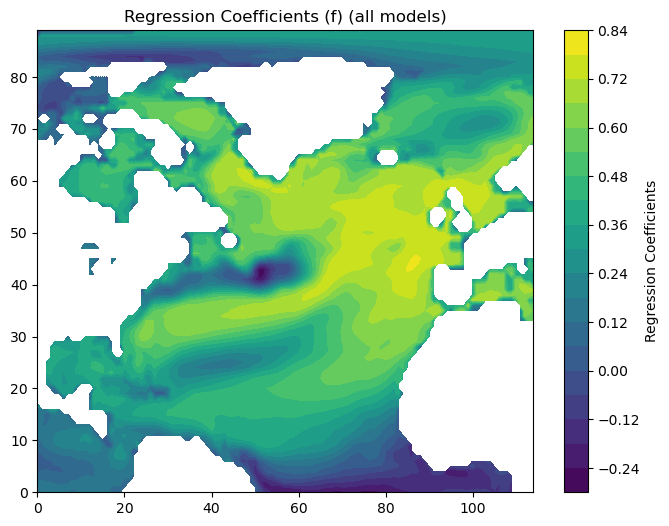

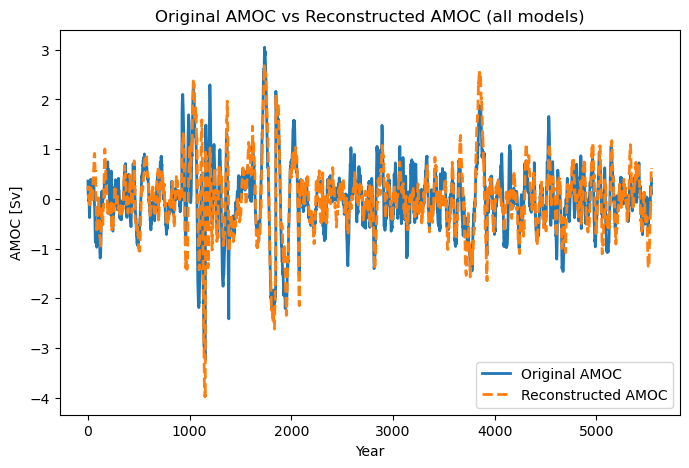

In [39]:
sst_matrices = [sst_multiple_models[key] for key in sst_multiple_models]
sst_all = np.vstack(sst_matrices)

amoc_matrices = [amoc_multiple_models[key] for key in amoc_multiple_models]
amoc_all = np.hstack(amoc_matrices).T

sst_all = xr.DataArray(
    sst_all,
    dims=["year", "lat", "lon"],
    coords={"year": np.arange(sst_all.shape[0]), "lat": sst.lat.values, "lon": sst.lon.values},
    name="sst"
)

amoc_all = xr.DataArray(
    amoc_all,
    dims=["year"],
    coords={"year": np.arange(amoc_all.shape[0])},
    name="amoc"
)


# Prepare and normalize data    
sst_normalized = prepare_and_normalize_sst(sst_all)
amoc, amoc_normalized, amoc_mean, amoc_std = prepare_and_normalize_amoc(amoc_all)

# Train regression and reconstruct AMOC
f, amoc_reconstructed = train_regression_and_reconstruct(sst_normalized, amoc_normalized, amoc_std)

years = sst_all.year.values
save_regression_map_sst_amoc_to_file(f, ny, nx, years, sst_smoothed, sst_normalized, amoc_normalized, amoc_std, amoc_reconstructed, 'multimodel', PATH_saved_regressions, smoothing_period = running_mean_window)

# Plot regression coefficients
plot_regression_coefficients(f, ny, nx, f"Regression Coefficients (f) (all models)")

# Plot AMOC comparison
years = sst_all.year.values
plot_amoc_comparison(amoc, amoc_reconstructed, years, 
                     f"Original AMOC vs Reconstructed AMOC (all models)", smoothing_period = running_mean_window)


# For each model, reconstruct AMOC based on every possible regression pattern 


ACCESS-CM2
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


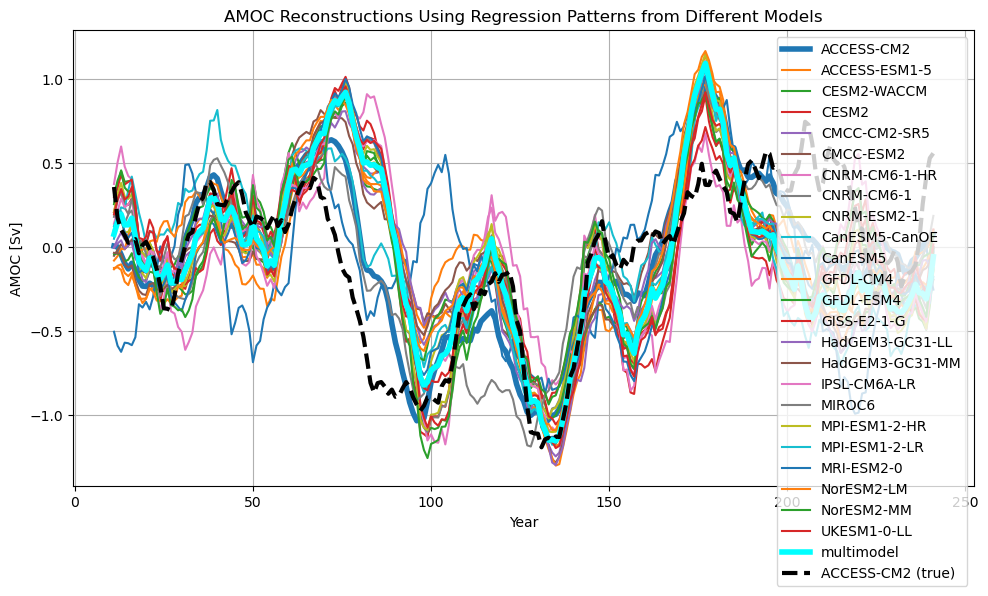

ACCESS-ESM1-5
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


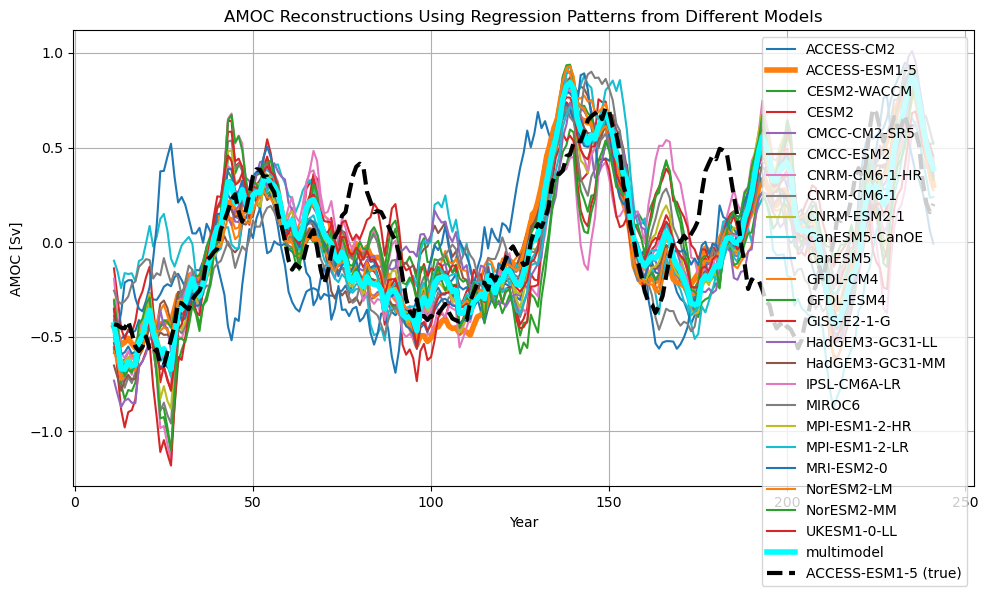

CESM2-WACCM
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


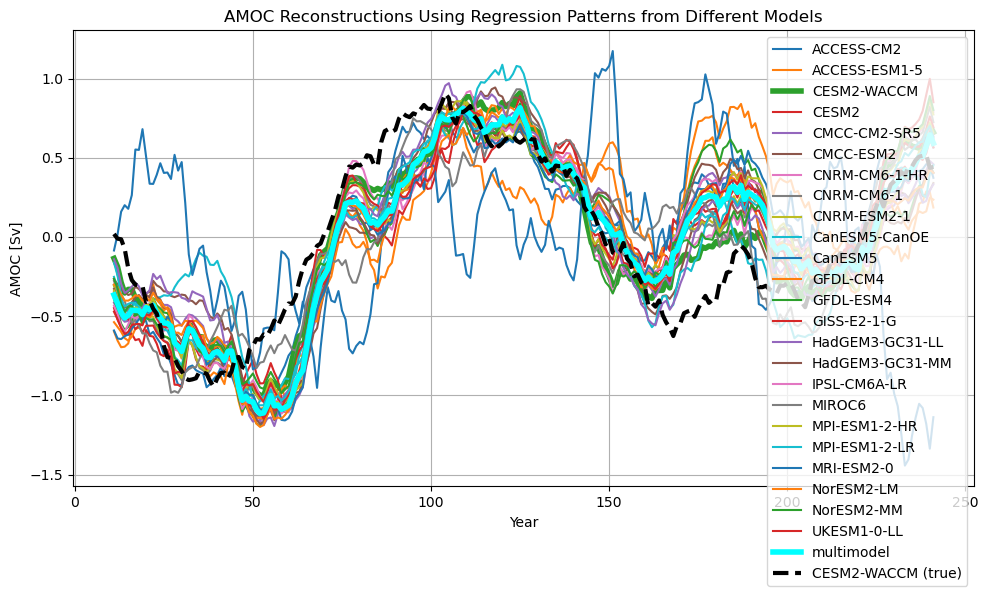

CESM2
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


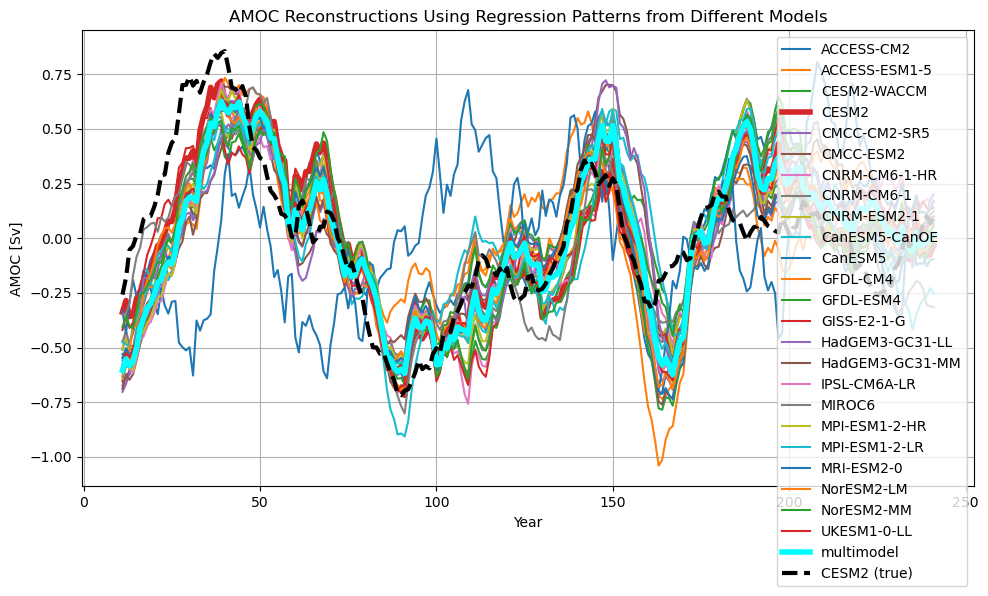

CMCC-CM2-SR5
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


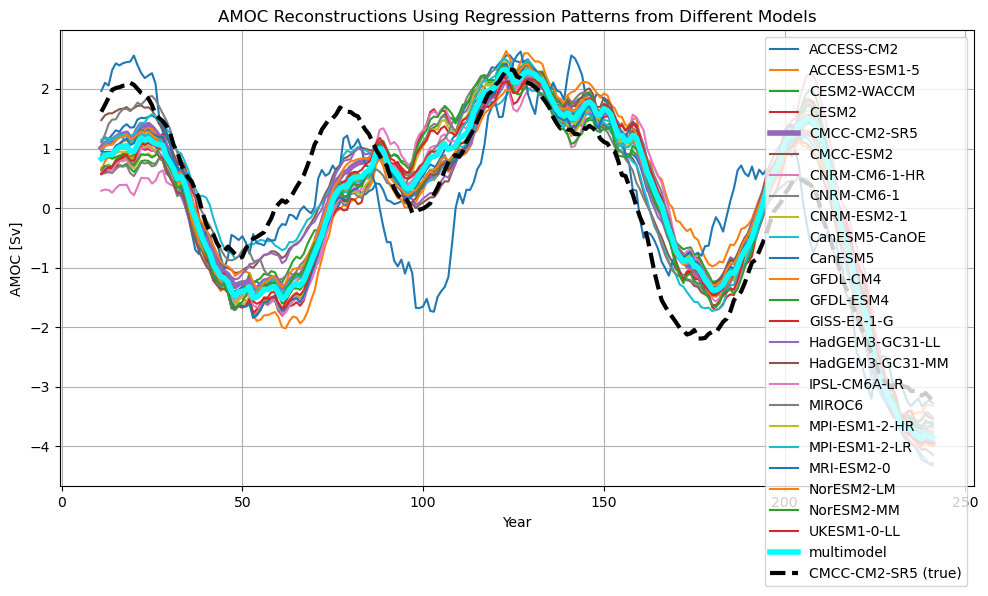

CMCC-ESM2
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


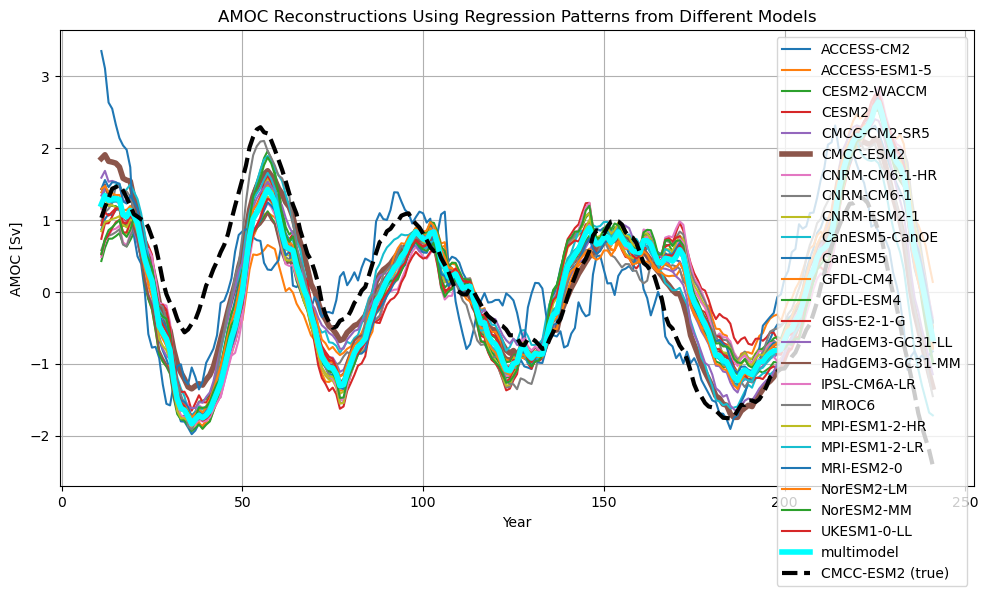

CNRM-CM6-1-HR
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


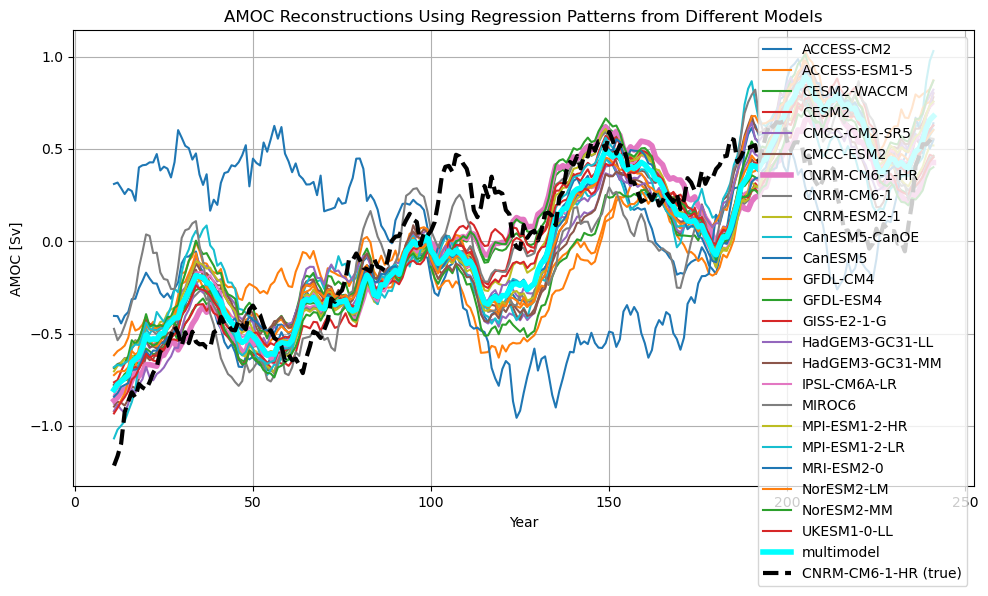

CNRM-CM6-1
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


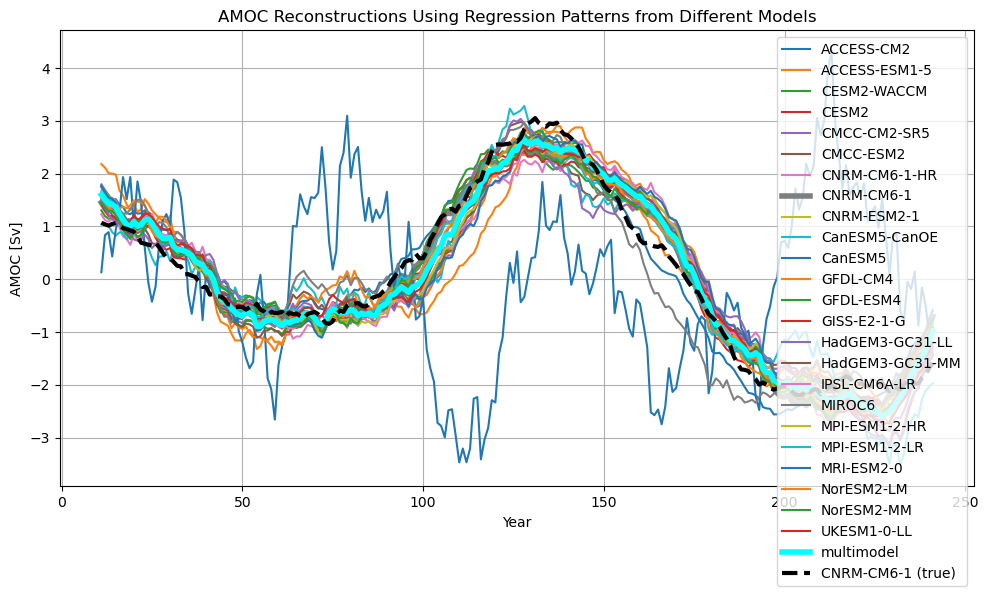

CNRM-ESM2-1
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


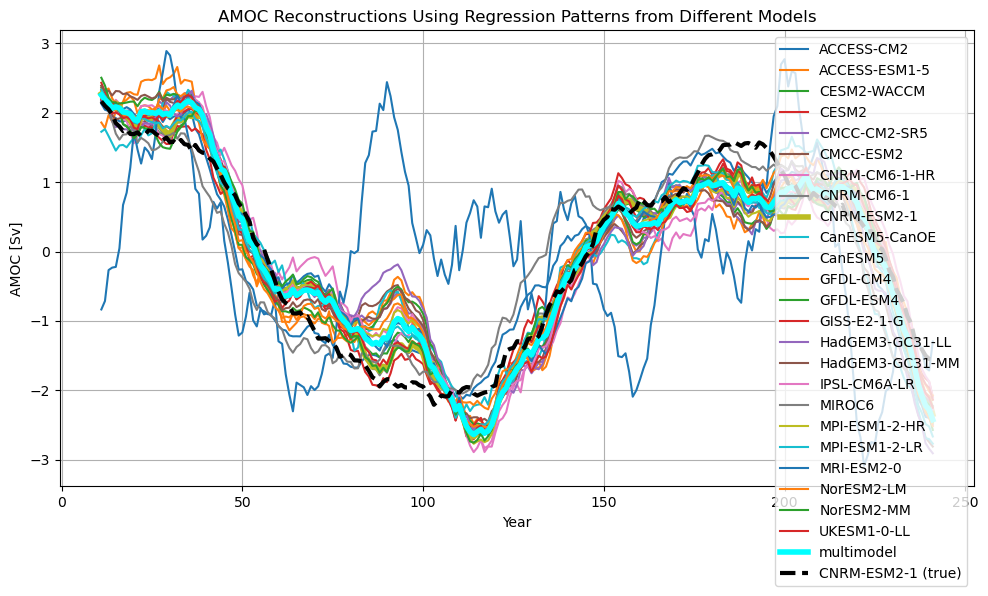

CanESM5-CanOE
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


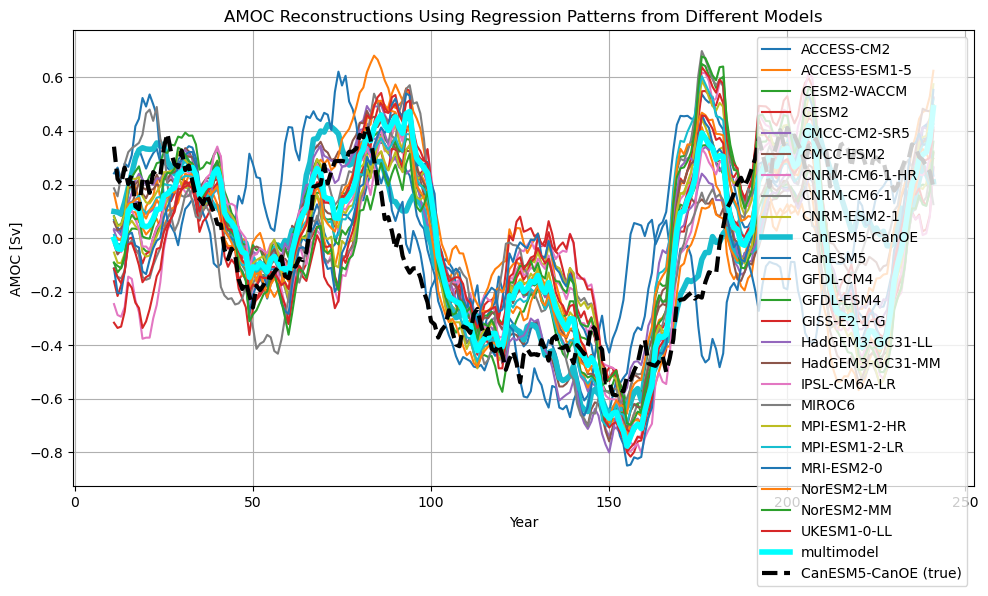

CanESM5
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


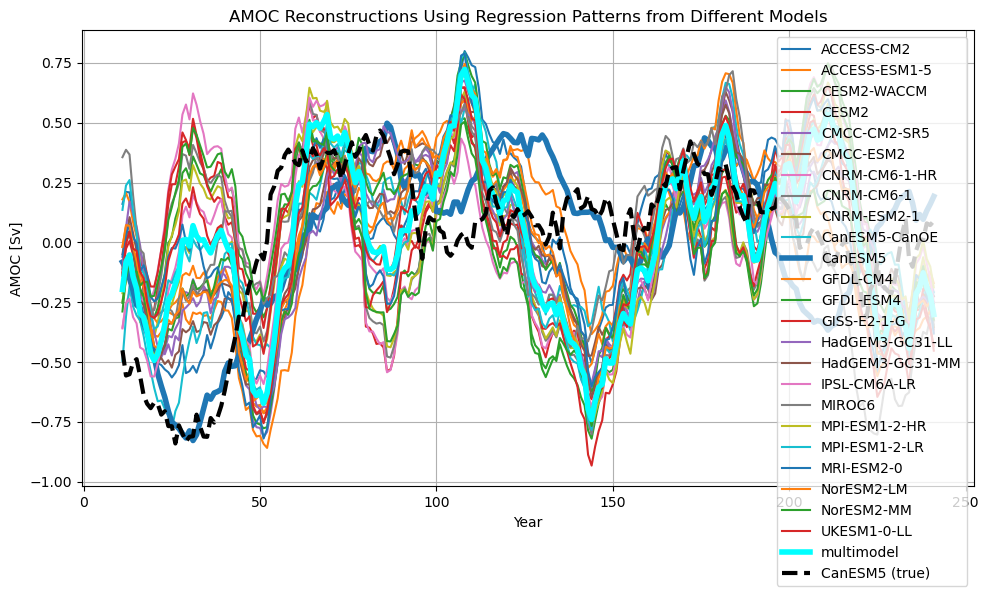

GFDL-CM4
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


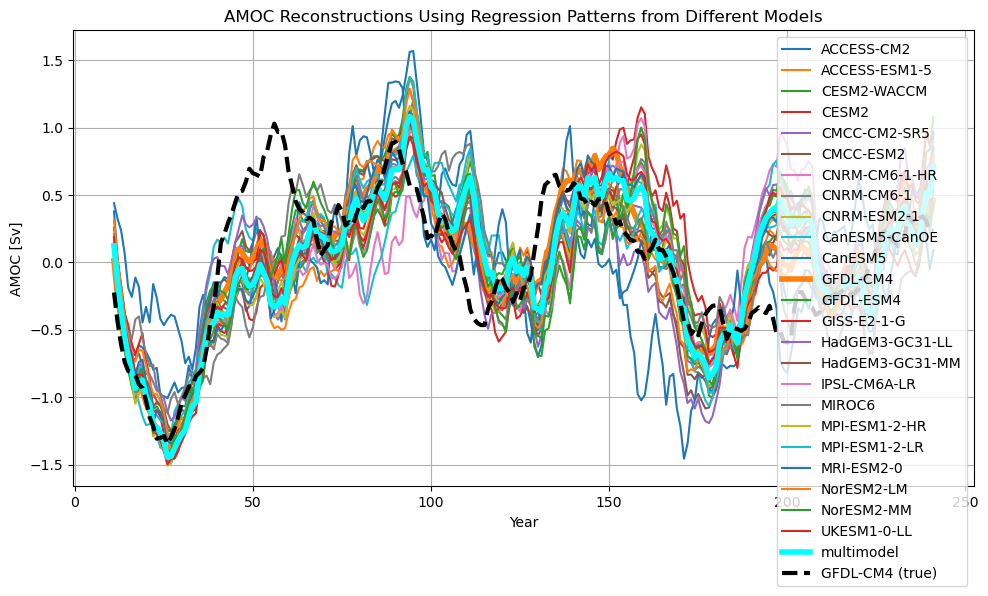

GFDL-ESM4
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


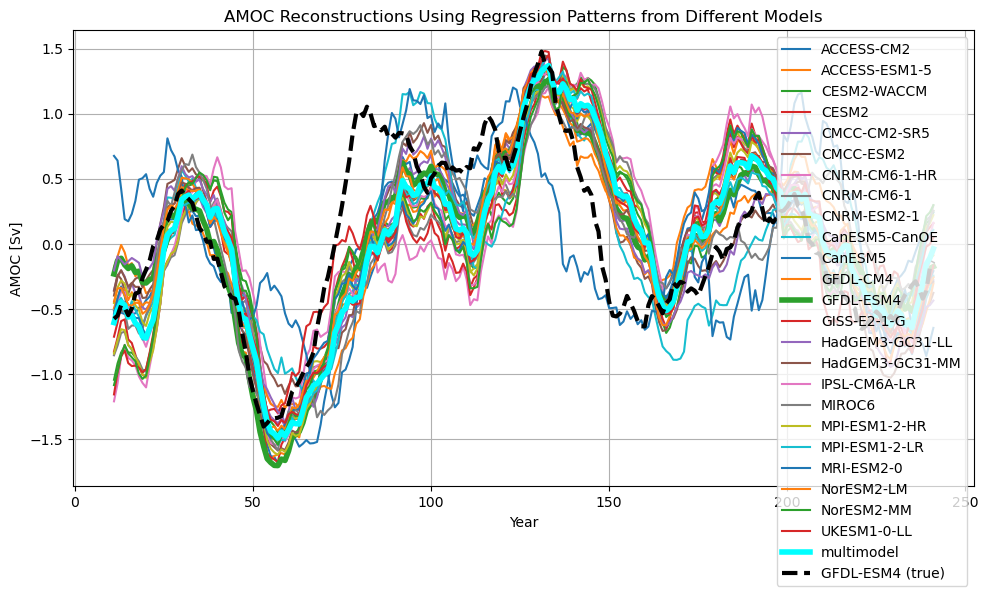

GISS-E2-1-G
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


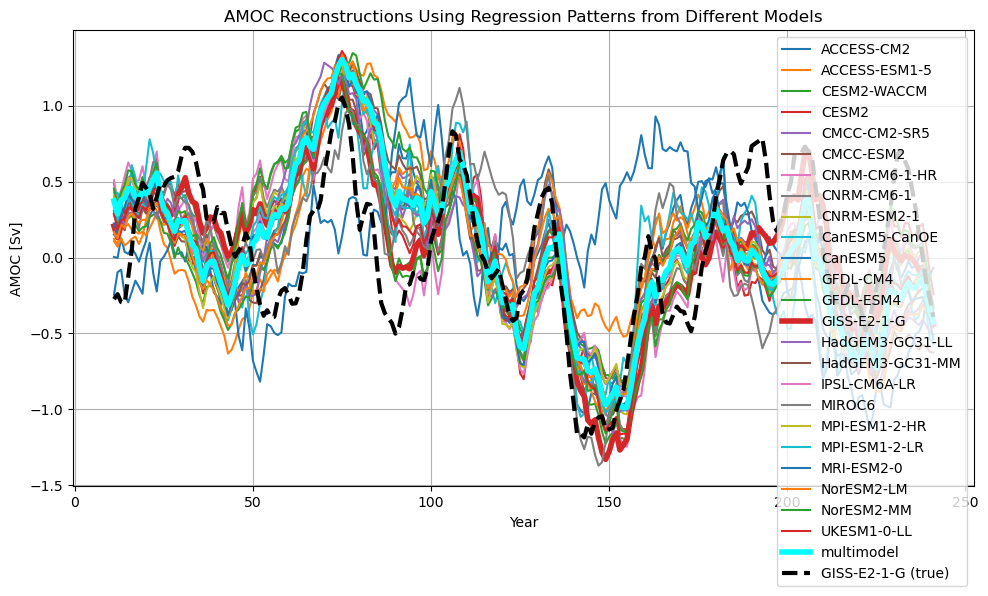

HadGEM3-GC31-LL
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


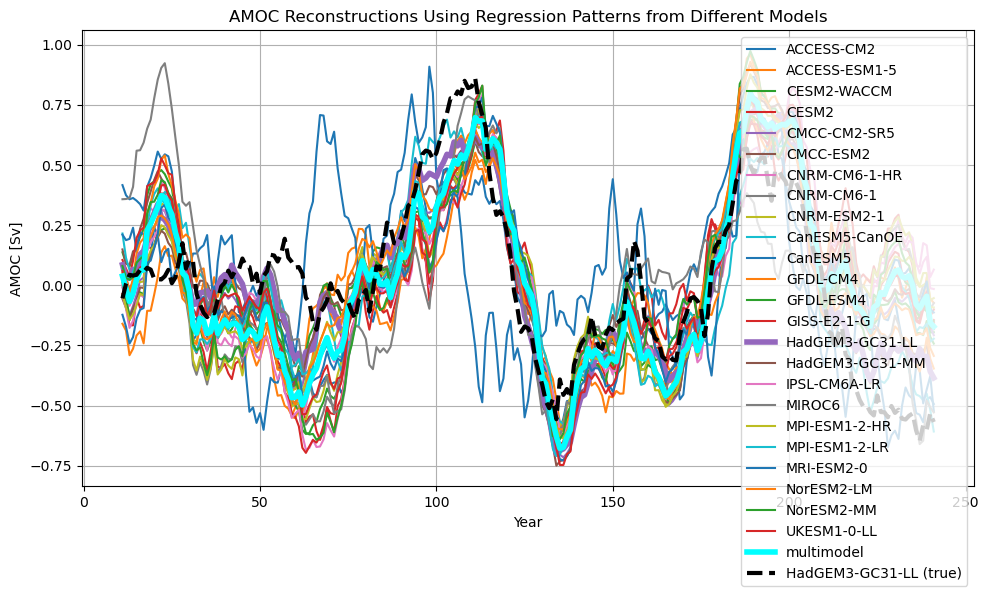

HadGEM3-GC31-MM
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


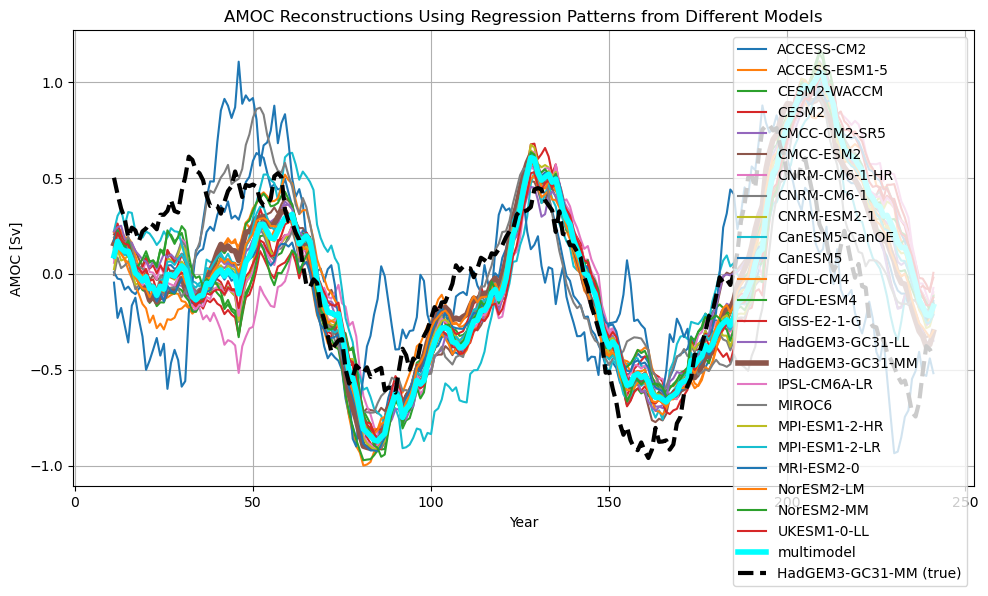

IPSL-CM6A-LR
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


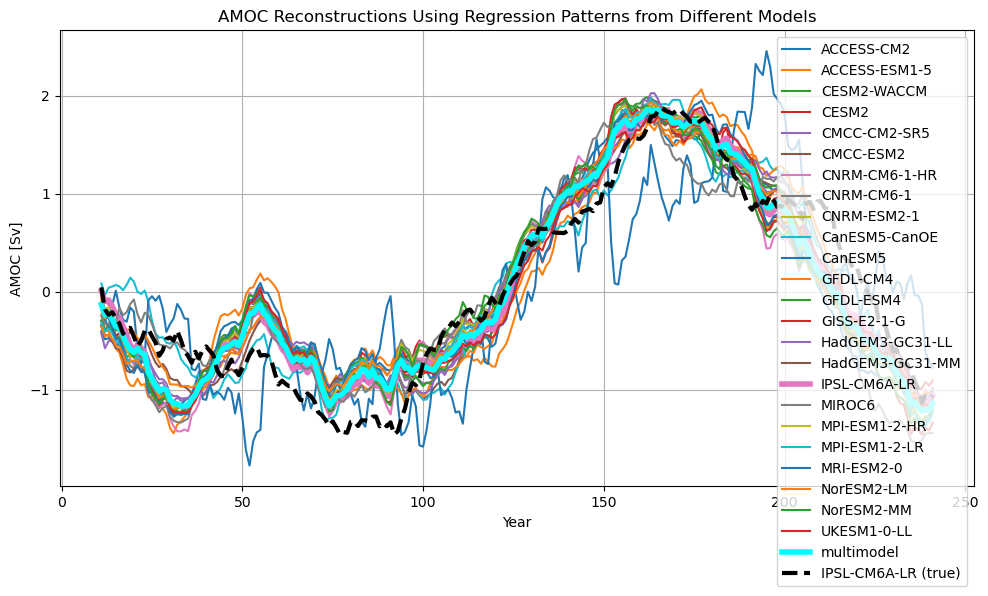

MIROC6
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


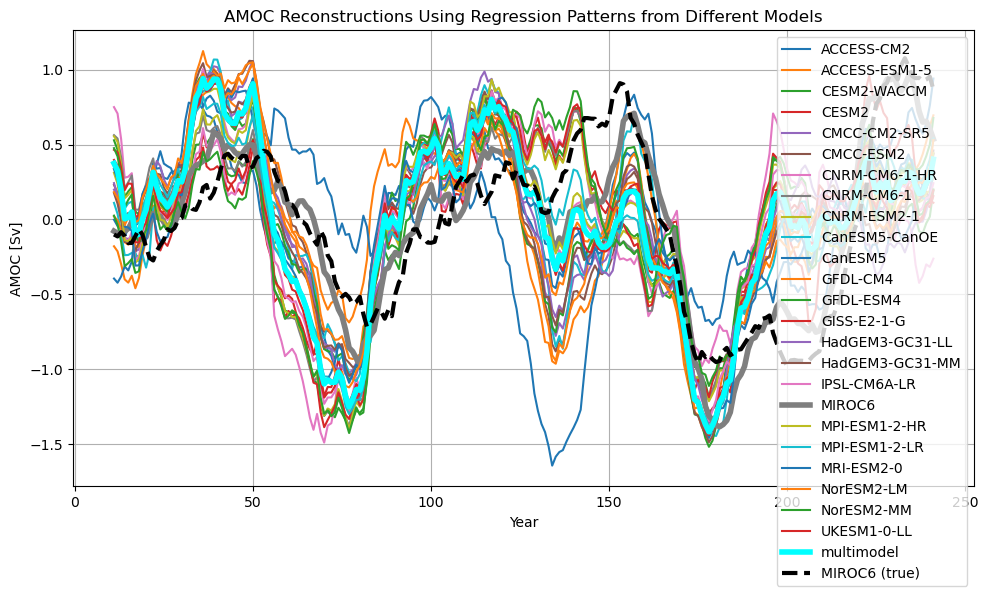

MPI-ESM1-2-HR
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


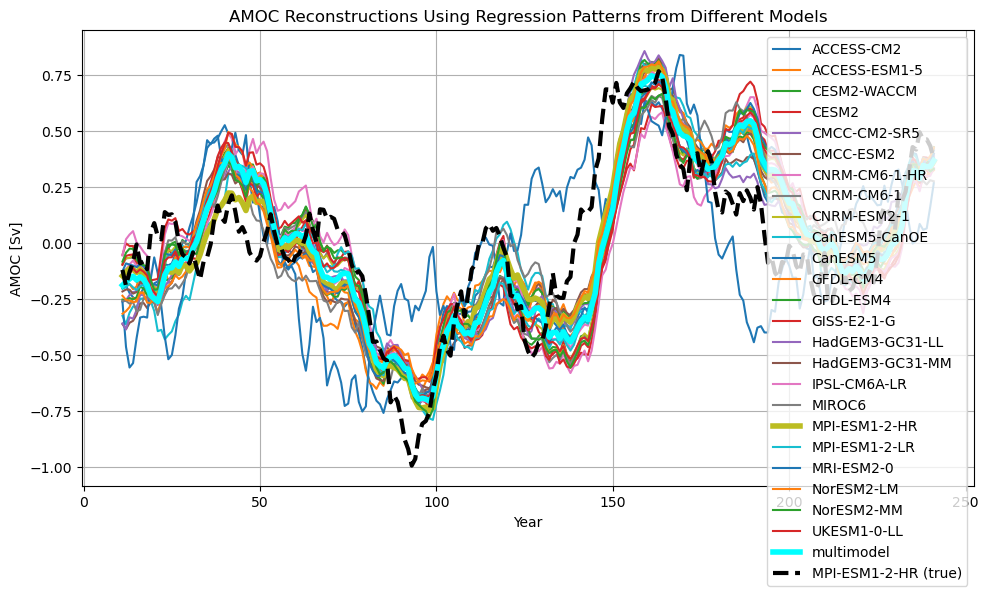

MPI-ESM1-2-LR
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


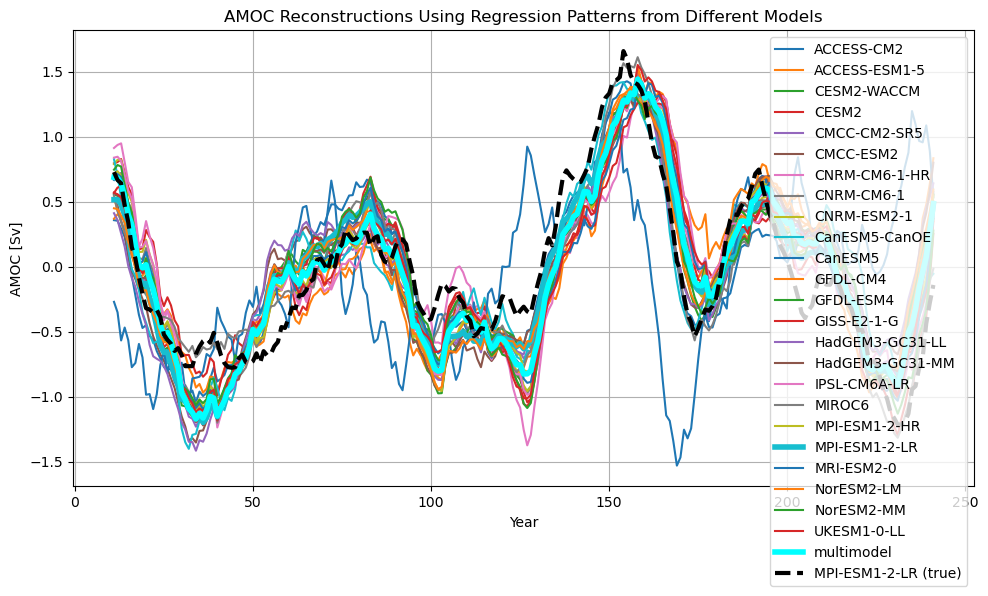

MRI-ESM2-0
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


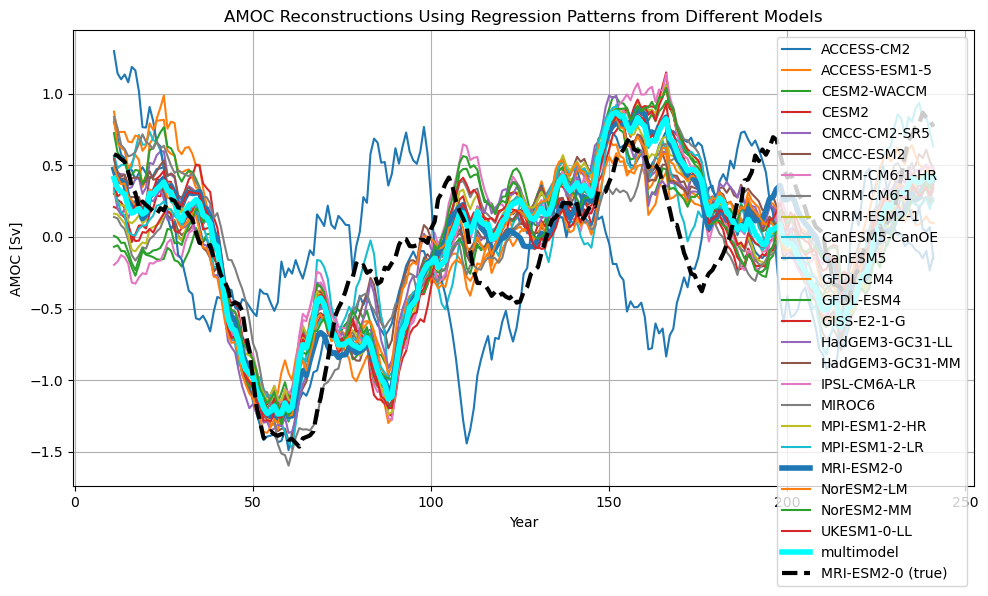

NorESM2-LM
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


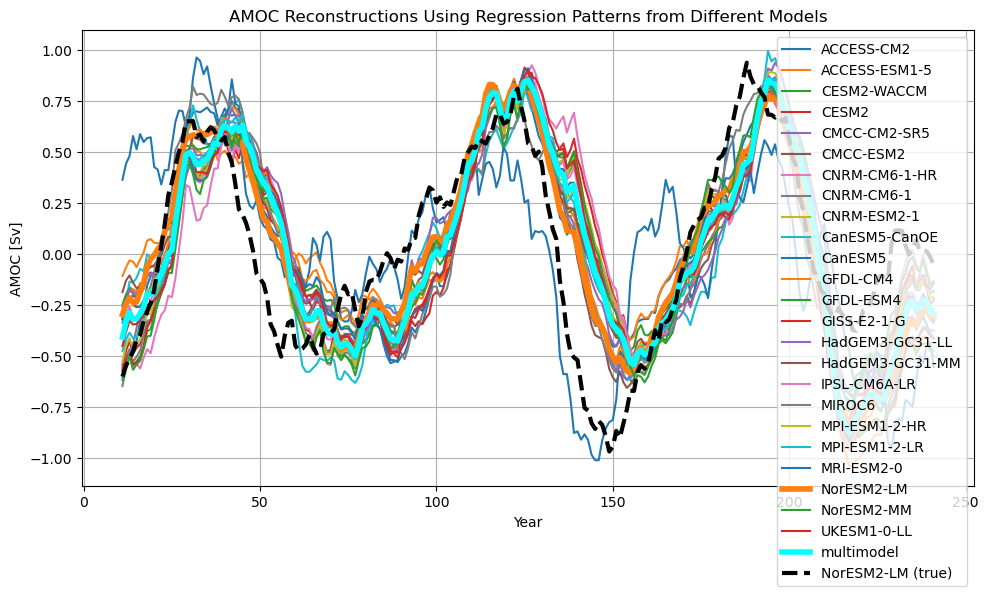

NorESM2-MM
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


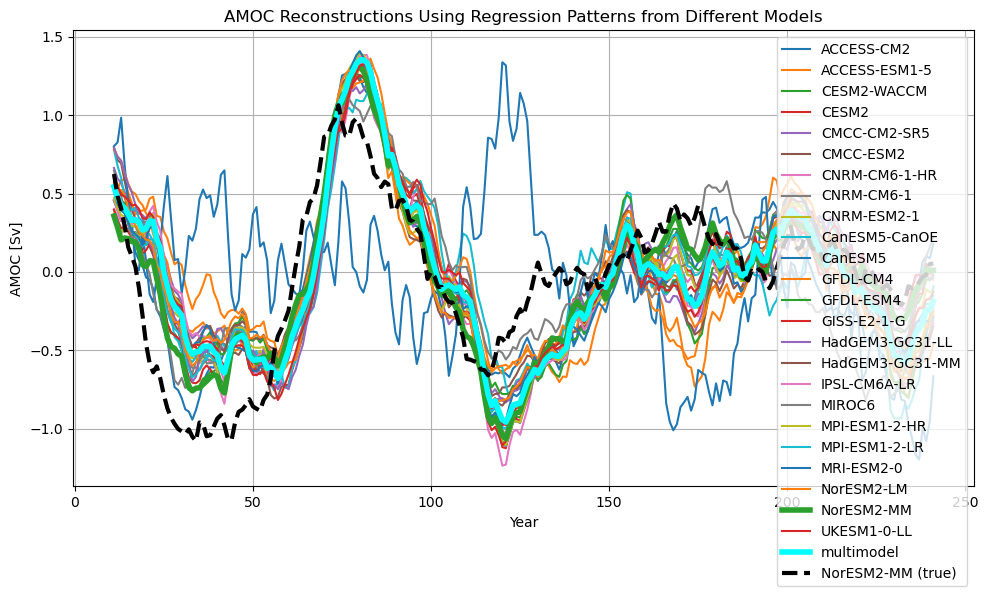

UKESM1-0-LL
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


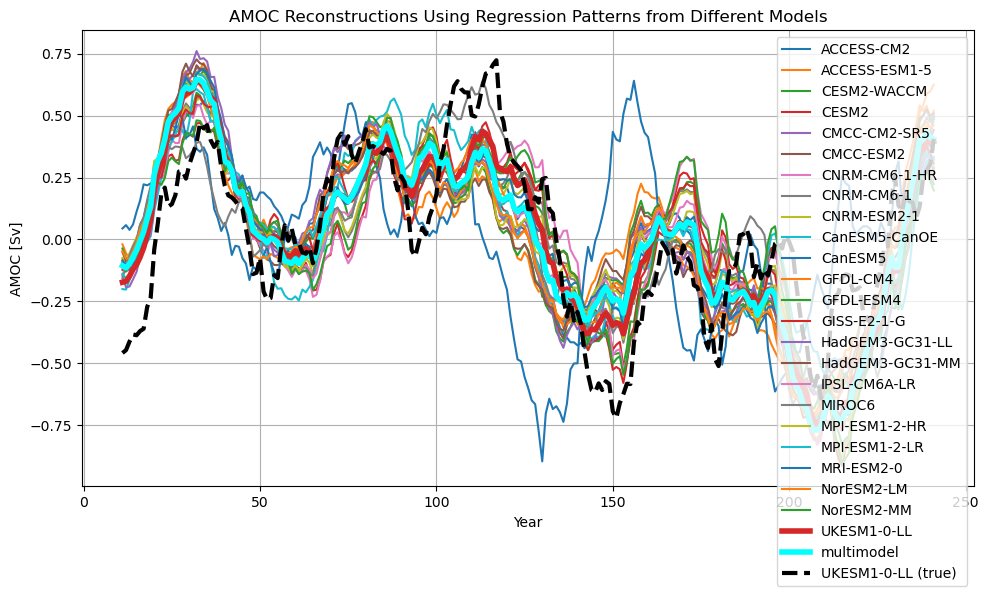

In [37]:
for i, model in enumerate(model_names):
    filename_amoc = PATH_AMOC + 'amoc_' + scenario + '_' + amoc_institution_names[i] + '_' + model + '_' + ens_members_appendices[i] + '.nc'
    filename_sst = PATH_SST + 'tos_Omon_' + model + '_' + scenario + '_' + ens_members_appendices[i] + '.nc'
    if os.path.exists(filename_amoc) and os.path.exists(filename_sst):

        print(model)
        
        sst_time_series = xr.open_dataset(filename_sst)['tos'].sel(lat = slice(lat_min, lat_max), lon = slice(lon_min, lon_max))
        sst_time_series['year'] = xr.DataArray(np.arange(1, len(sst_time_series['year'].values)+1), dims = 'year')
        sst_mean = sst_time_series.mean('year')
        sst_smoothed = (sst_time_series - sst_mean).rolling(year=running_mean_window, center=True).mean().dropna(dim='year', how='all')

        sst = sst_smoothed

        sst_normalized = prepare_and_normalize_sst(sst)

        # Get spatial grid dimensions for the North Atlantic region
        ny = sst.mean('year').shape[0]
        nx = sst.mean('year').shape[1]

        if model == 'IPSL-CM6A-LR':
            amoc_time_series = xr.open_dataset(filename_amoc)['amoc'].isel(year = slice(0, len(sst_time_series)), x = 0)
        else:
            amoc_time_series = xr.open_dataset(filename_amoc)['amoc'].isel(year = slice(0, len(sst_time_series)))
            
        amoc_mean = amoc_time_series.mean('year')
        amoc_smoothed = (amoc_time_series - amoc_mean).rolling(year=running_mean_window, center=True).mean().dropna(dim='year', how='all')
        amoc_smoothed['year'] = xr.DataArray(np.arange(1 + running_mean_window/2, 251 - running_mean_window/2 + 1), dims = 'year')

        amoc = amoc_smoothed

        # Get spatial grid dimensions for the North Atlantic region
        ny = sst.mean('year').shape[0]
        nx = sst.mean('year').shape[1]
    
        # Prepare and normalize data    
        sst_normalized = prepare_and_normalize_sst(sst)
        amoc, amoc_normalized, amoc_mean, amoc_std = prepare_and_normalize_amoc(amoc)

        amoc_recon_with_regressions_from_different_models = xr.Dataset()
        
        for imr, model_regr in enumerate(model_names):
            print(model_regr)
            regression_pattern = xr.open_dataset(PATH_saved_regressions + model_regr + '_231yrs.nc').fr.fillna(0).values.flatten()

            amoc_reconstructed = sst_normalized @ regression_pattern
            amoc_reconstructed = amoc_reconstructed * amoc_std / np.std(amoc_reconstructed) + amoc_mean

            amoc_recon_with_regressions_from_different_models[model_regr] = xr.DataArray(amoc_reconstructed,
                                                                                         dims=["year"],
                                                                                         coords={"year": np.arange(1 + running_mean_window/2, 251 - running_mean_window/2 + 1)},
                                                                                         name=model_regr)

        
        # Adding reconstruction computed using regression pattern from multi-model regression

        regression_pattern = xr.open_dataset(PATH_saved_regressions + 'multimodel_5544yrs.nc').fr.fillna(0).values.flatten()
        amoc_reconstructed = sst_normalized @ regression_pattern
        amoc_reconstructed = amoc_reconstructed * amoc_std / np.std(amoc_reconstructed) + amoc_mean

        amoc_recon_with_regressions_from_different_models['multimodel'] = xr.DataArray(amoc_reconstructed,
                                                                                         dims=["year"],
                                                                                         coords={"year": np.arange(1 + running_mean_window/2, 251 - running_mean_window/2 + 1)},
                                                                                         name=model_regr)




        
        # amoc_recon_with_regressions_from_different_models.to_netcdf(PATH_saved_cross_regressions + '/SST_from_' + model + '_regression_patterns_from_all_models.nc')
        plt.figure(figsize=(10, 6))

        for model_regr in amoc_recon_with_regressions_from_different_models.data_vars:
            if model_regr == model:
                da = amoc_recon_with_regressions_from_different_models[model_regr]
                plt.plot(da["year"], da, label=model_regr, linewidth = 4)
            elif model_regr == 'multimodel':
                da = amoc_recon_with_regressions_from_different_models[model_regr]
                plt.plot(da["year"], da, label=model_regr, linewidth = 4, c = 'cyan')
            else:
                da = amoc_recon_with_regressions_from_different_models[model_regr]
                plt.plot(da["year"], da, label=model_regr)

        plt.plot(amoc_smoothed['year'], amoc_smoothed, label = model + ' (true)', color='black', linewidth=3, linestyle='--')
        
                
        
        plt.title("AMOC Reconstructions Using Regression Patterns from Different Models")
        plt.xlabel("Year")
        plt.ylabel("AMOC [Sv]")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Compute multi-model regression pattern (excluding one model)
and save these to files

Excluding model: 0
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/multimodel_excl_ACCESS-CM2_5313yrs.nc


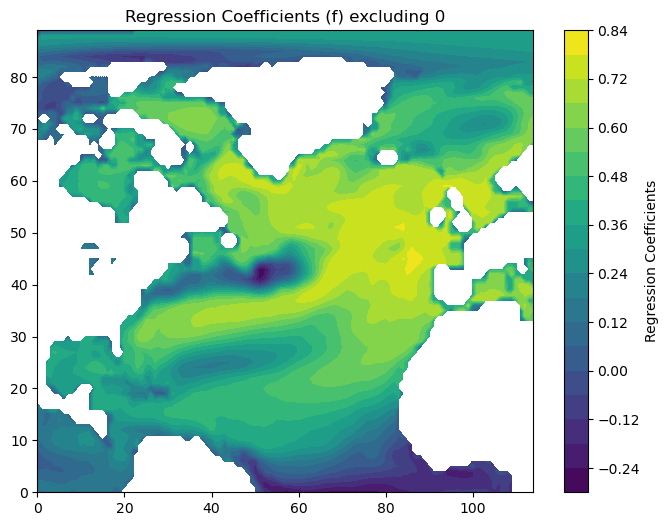

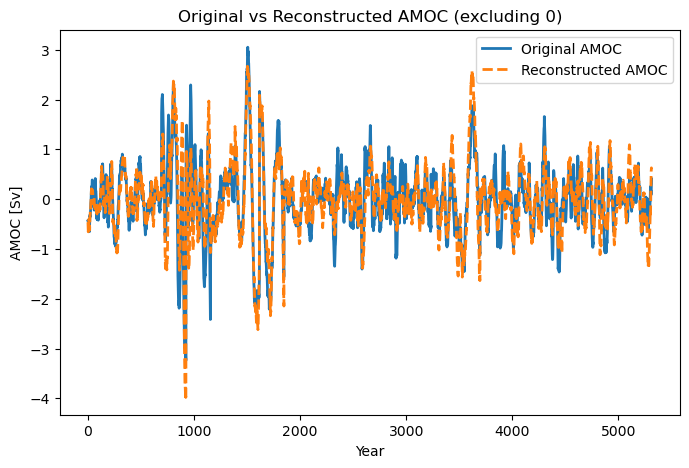

[0] f range: -0.2769 to 0.7905
[0] AMOC range: -3.2411 to 3.0513
[0] Reconstructed AMOC range: -3.9770 to 2.6690
Excluding model: 1
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/multimodel_excl_ACCESS-ESM1-5_5313yrs.nc


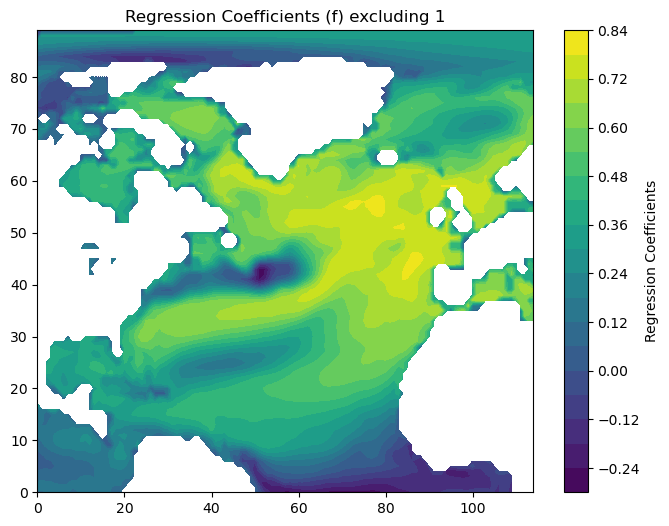

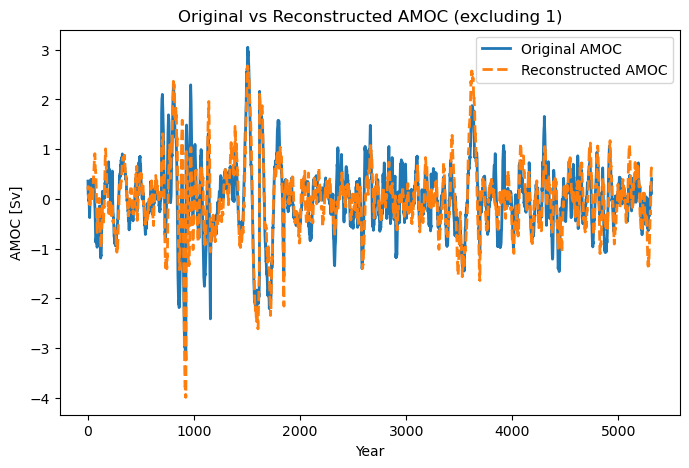

[1] f range: -0.2785 to 0.8028
[1] AMOC range: -3.2411 to 3.0513
[1] Reconstructed AMOC range: -3.9922 to 2.6761
Excluding model: 2
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/multimodel_excl_CESM2-WACCM_5313yrs.nc


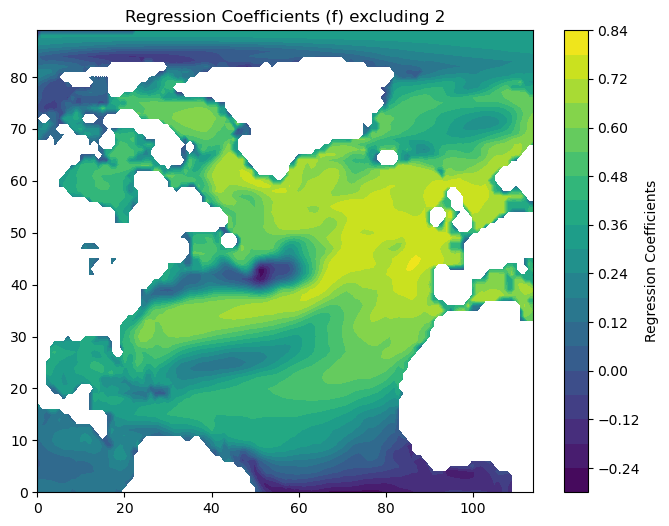

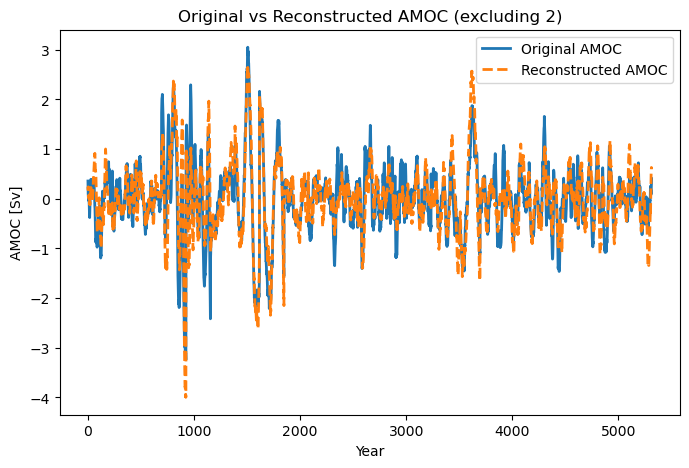

[2] f range: -0.2717 to 0.7883
[2] AMOC range: -3.2411 to 3.0513
[2] Reconstructed AMOC range: -3.9946 to 2.6801
Excluding model: 3
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/multimodel_excl_CESM2_5313yrs.nc


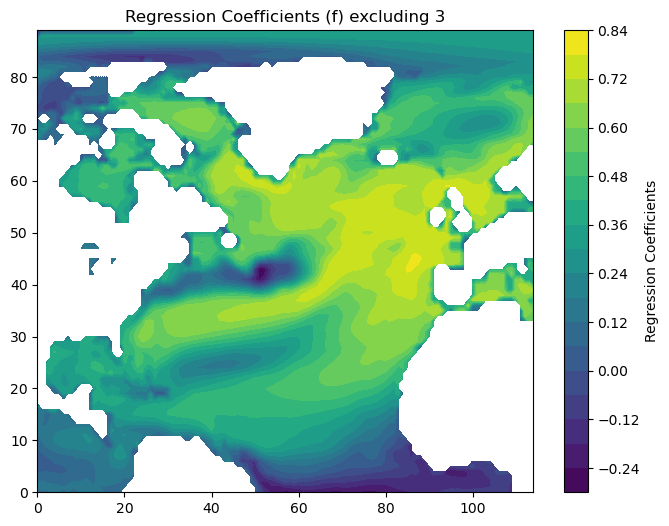

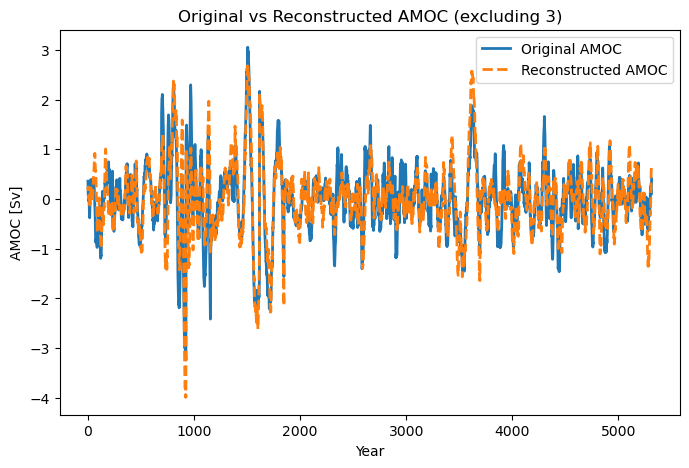

[3] f range: -0.2841 to 0.7903
[3] AMOC range: -3.2411 to 3.0513
[3] Reconstructed AMOC range: -3.9869 to 2.6780
Excluding model: 4
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/multimodel_excl_CMCC-CM2-SR5_5313yrs.nc


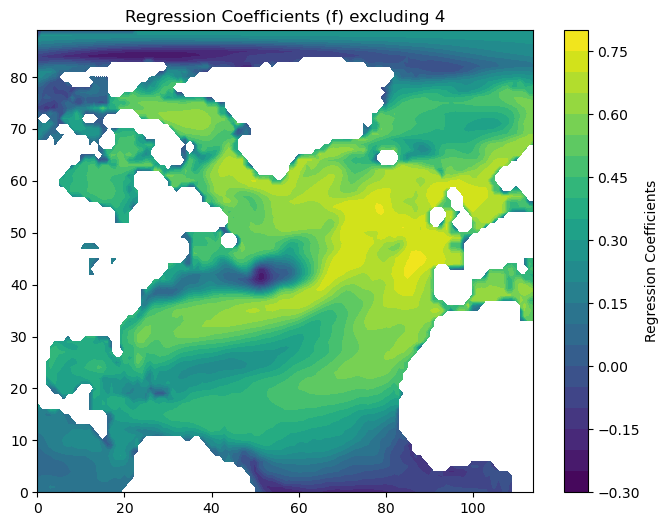

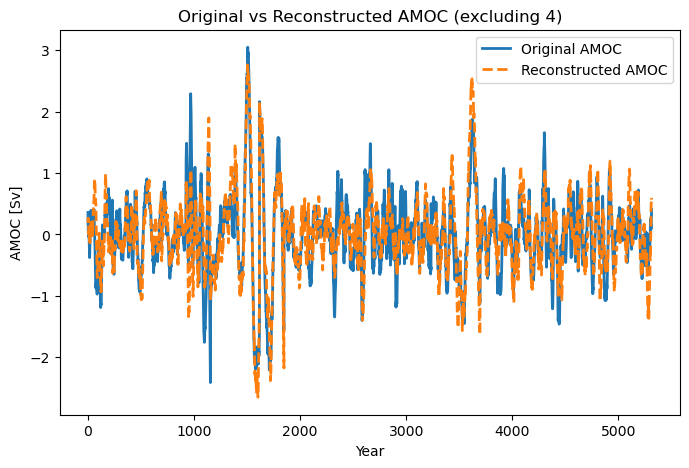

[4] f range: -0.2604 to 0.7704
[4] AMOC range: -2.4157 to 3.0513
[4] Reconstructed AMOC range: -2.6545 to 2.7618
Excluding model: 5
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/multimodel_excl_CMCC-ESM2_5313yrs.nc


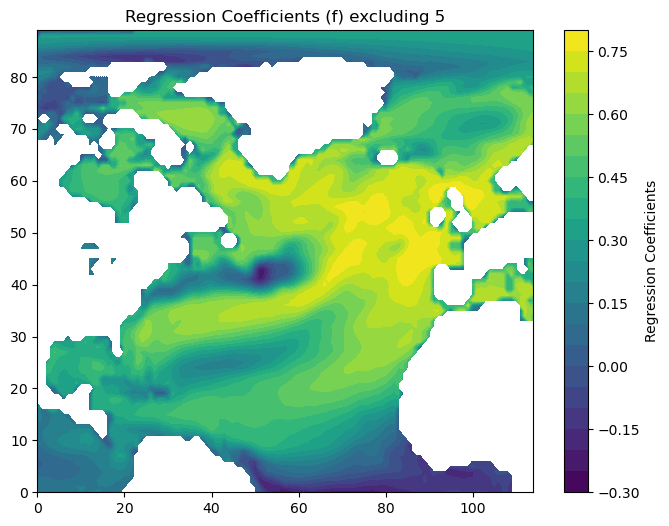

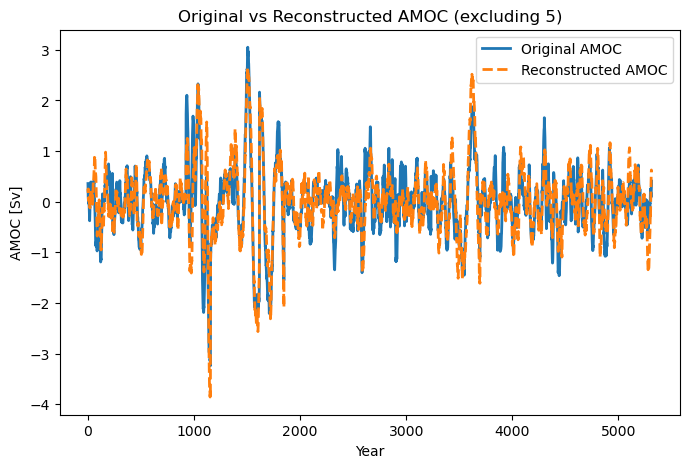

[5] f range: -0.2503 to 0.7896
[5] AMOC range: -3.2411 to 3.0513
[5] Reconstructed AMOC range: -3.8636 to 2.6284
Excluding model: 6
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/multimodel_excl_CNRM-CM6-1-HR_5313yrs.nc


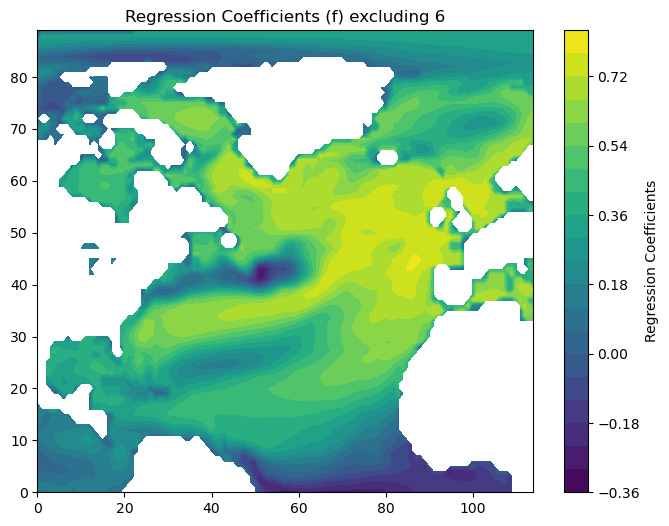

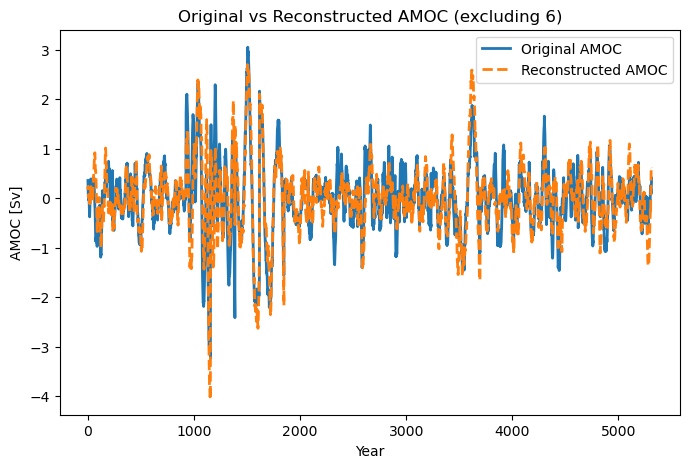

[6] f range: -0.3054 to 0.7891
[6] AMOC range: -3.2411 to 3.0513
[6] Reconstructed AMOC range: -4.0234 to 2.6988
Excluding model: 7
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/multimodel_excl_CNRM-CM6-1_5313yrs.nc


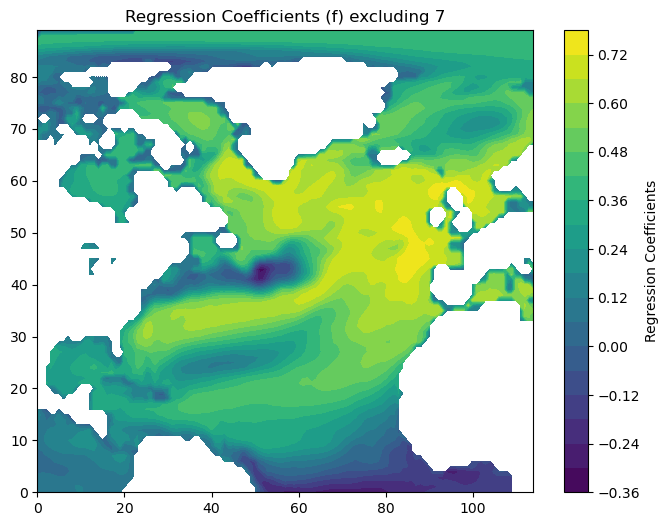

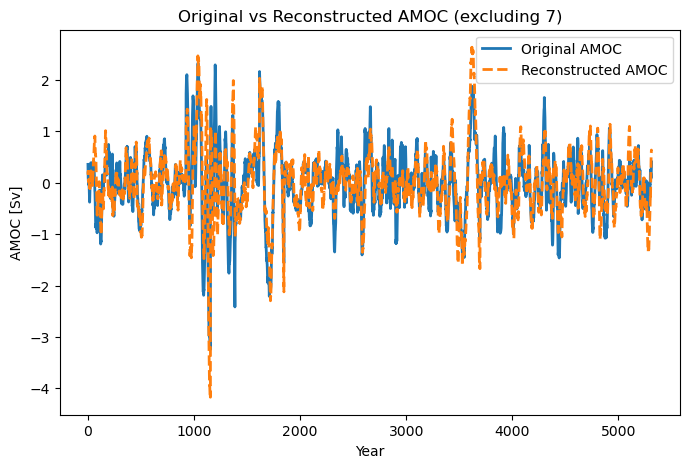

[7] f range: -0.3163 to 0.7575
[7] AMOC range: -3.2411 to 2.3273
[7] Reconstructed AMOC range: -4.1725 to 2.6369
Excluding model: 8
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/multimodel_excl_CNRM-ESM2-1_5313yrs.nc


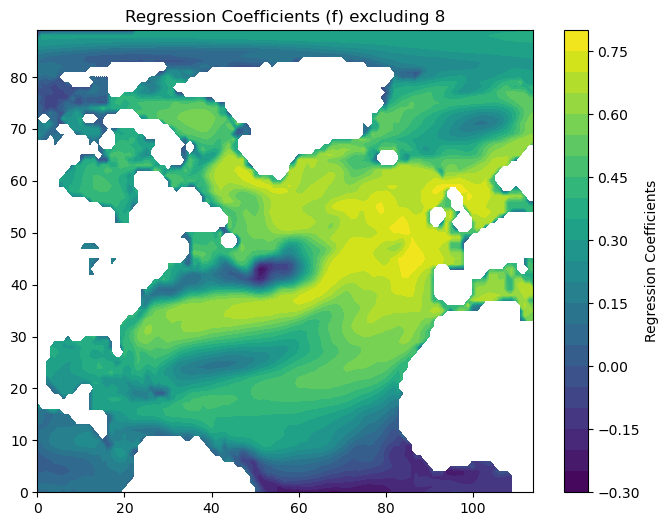

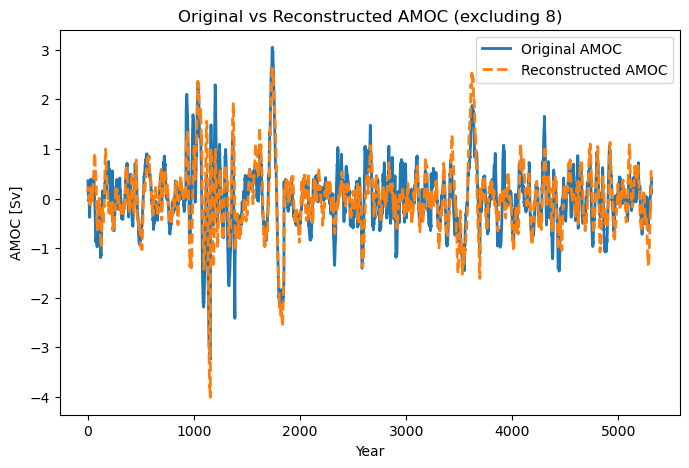

[8] f range: -0.2708 to 0.7732
[8] AMOC range: -3.2411 to 3.0513
[8] Reconstructed AMOC range: -4.0063 to 2.6312
Excluding model: 9
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/multimodel_excl_CanESM5-CanOE_5313yrs.nc


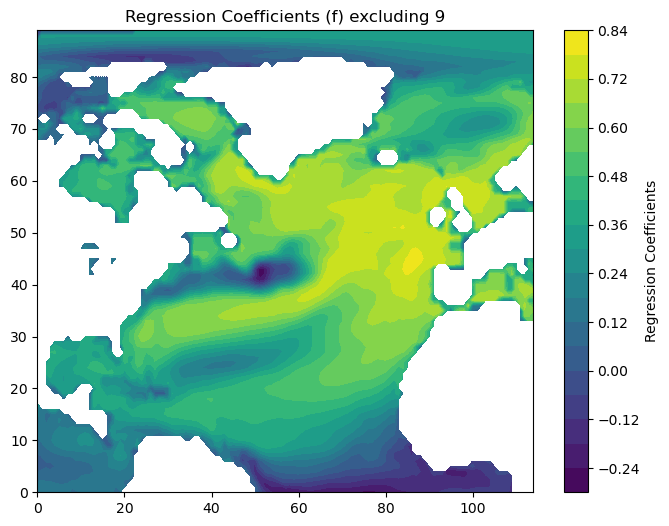

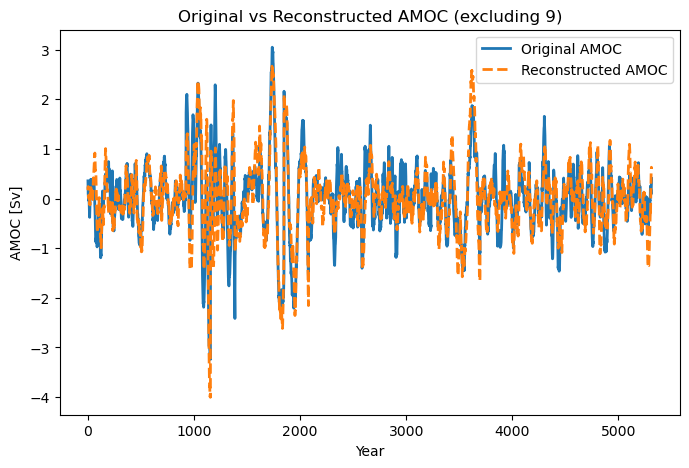

[9] f range: -0.2728 to 0.7988
[9] AMOC range: -3.2411 to 3.0513
[9] Reconstructed AMOC range: -4.0033 to 2.6690
Excluding model: 10
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/multimodel_excl_CanESM5_5313yrs.nc


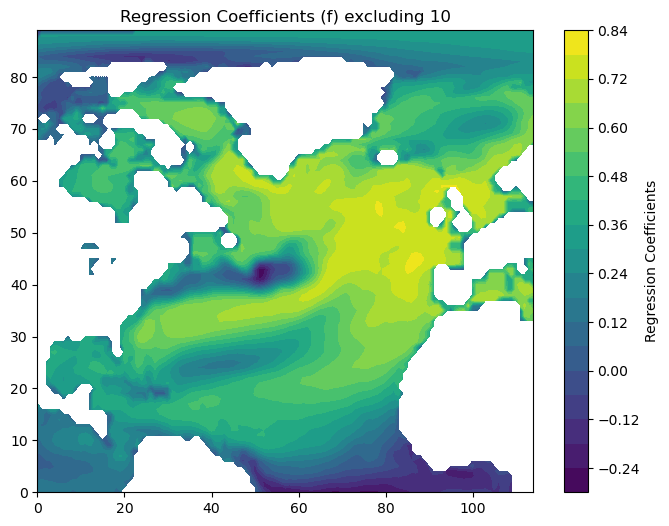

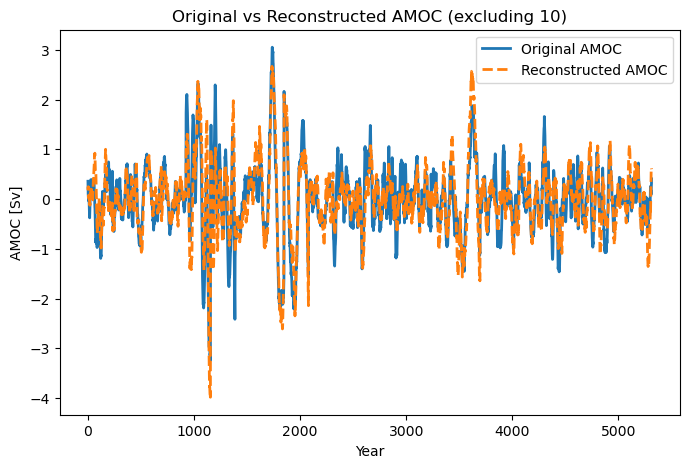

[10] f range: -0.2782 to 0.7925
[10] AMOC range: -3.2411 to 3.0513
[10] Reconstructed AMOC range: -3.9828 to 2.6666
Excluding model: 11
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/multimodel_excl_GFDL-CM4_5313yrs.nc


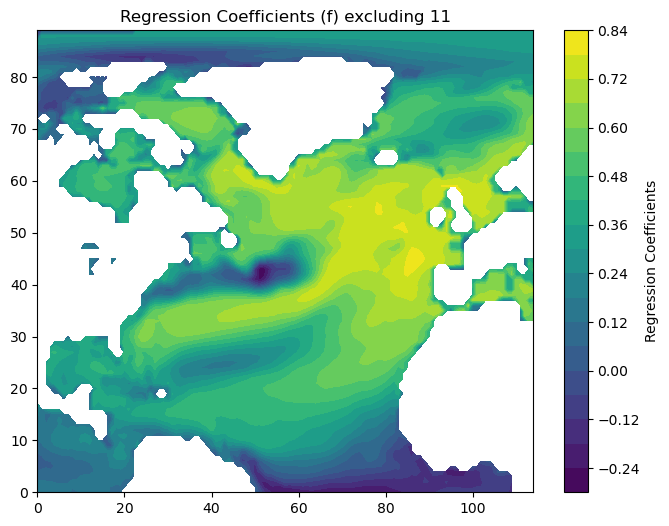

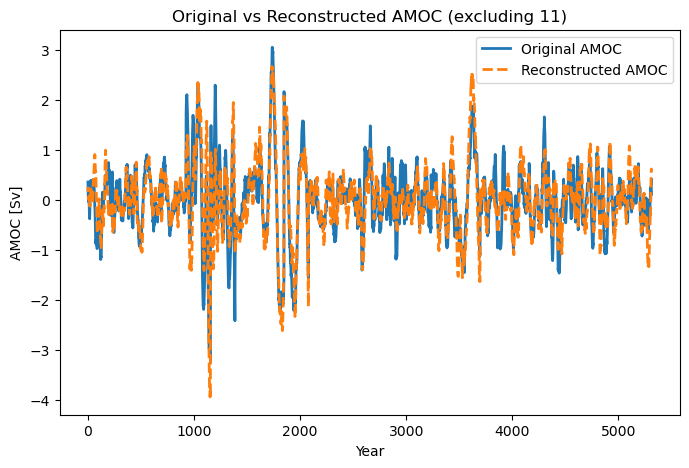

[11] f range: -0.2923 to 0.7985
[11] AMOC range: -3.2411 to 3.0513
[11] Reconstructed AMOC range: -3.9431 to 2.6668
Excluding model: 12
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/multimodel_excl_GFDL-ESM4_5313yrs.nc


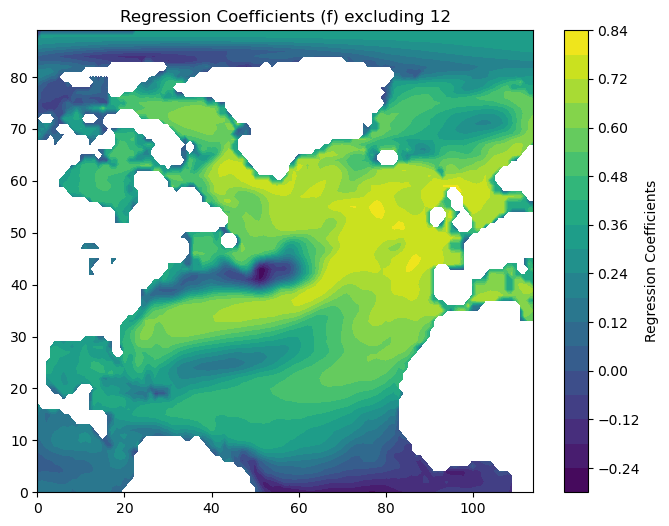

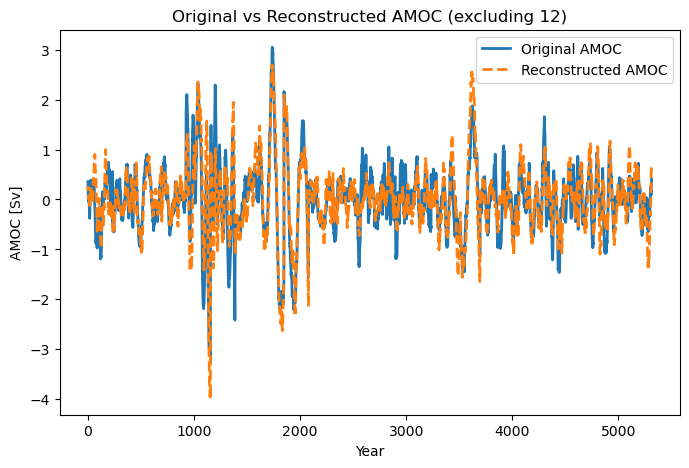

[12] f range: -0.2882 to 0.7895
[12] AMOC range: -3.2411 to 3.0513
[12] Reconstructed AMOC range: -3.9624 to 2.6955
Excluding model: 13
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/multimodel_excl_GISS-E2-1-G_5313yrs.nc


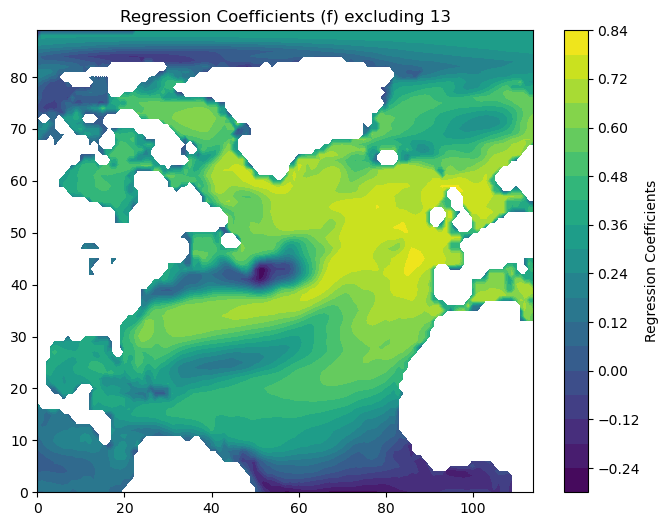

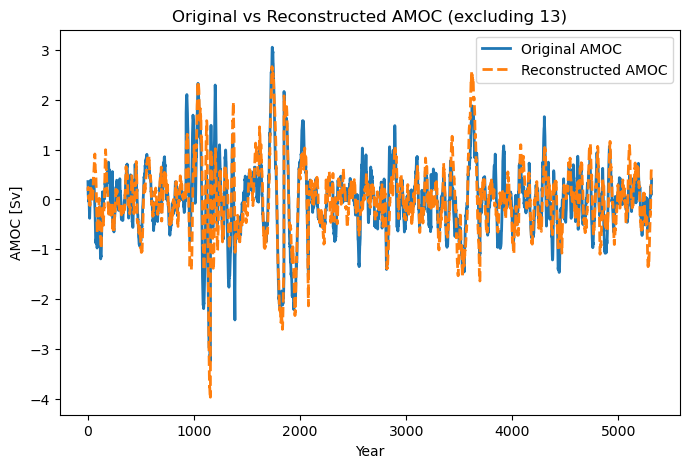

[13] f range: -0.2830 to 0.7969
[13] AMOC range: -3.2411 to 3.0513
[13] Reconstructed AMOC range: -3.9645 to 2.6627
Excluding model: 14
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/multimodel_excl_HadGEM3-GC31-LL_5313yrs.nc


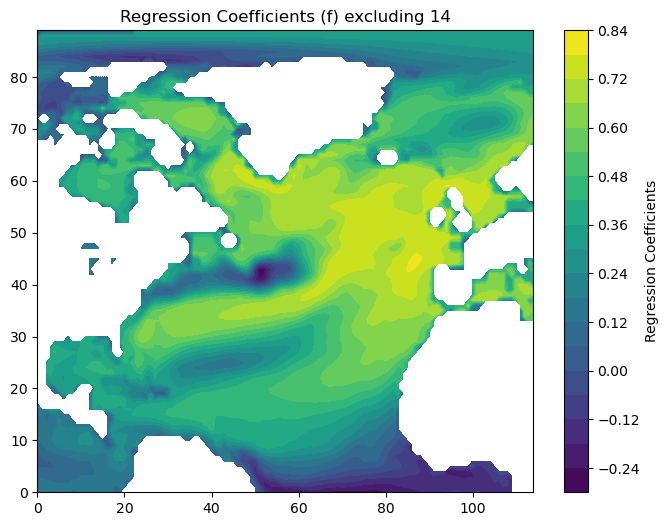

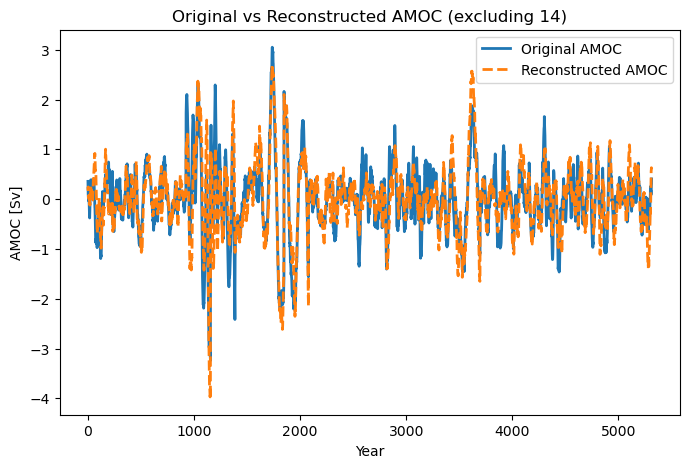

[14] f range: -0.2752 to 0.7901
[14] AMOC range: -3.2411 to 3.0513
[14] Reconstructed AMOC range: -3.9772 to 2.6753
Excluding model: 15
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/multimodel_excl_HadGEM3-GC31-MM_5313yrs.nc


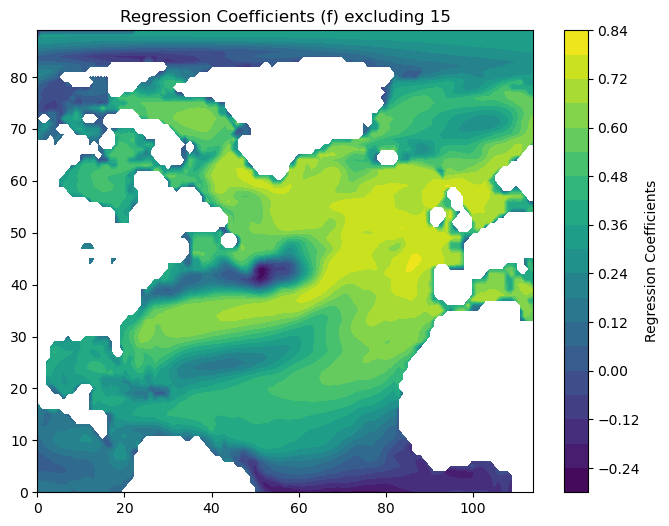

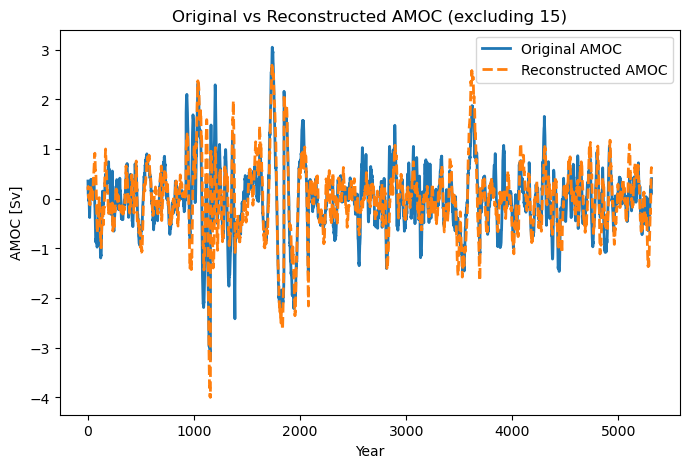

[15] f range: -0.2854 to 0.7903
[15] AMOC range: -3.2411 to 3.0513
[15] Reconstructed AMOC range: -3.9950 to 2.6898
Excluding model: 16
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/multimodel_excl_IPSL-CM6A-LR_5313yrs.nc


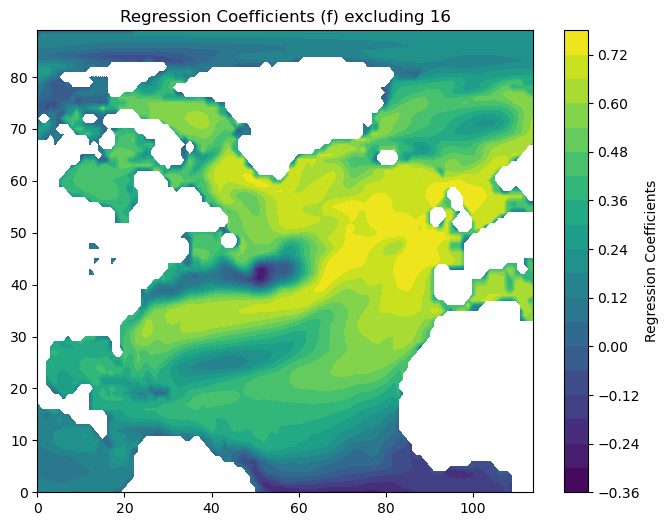

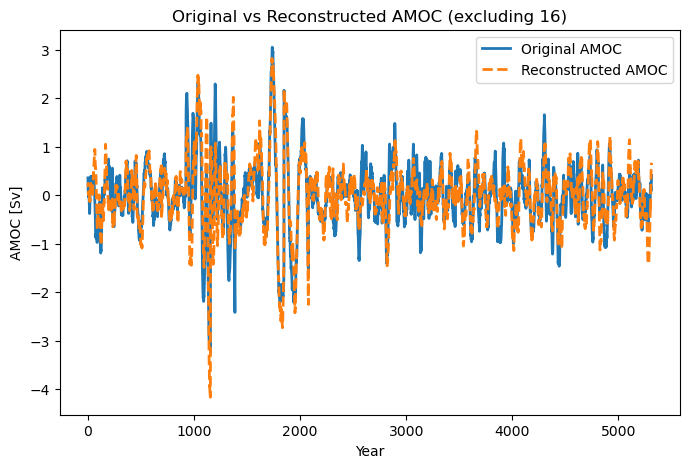

[16] f range: -0.3064 to 0.7796
[16] AMOC range: -3.2411 to 3.0513
[16] Reconstructed AMOC range: -4.1642 to 2.8200
Excluding model: 17
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/multimodel_excl_MIROC6_5313yrs.nc


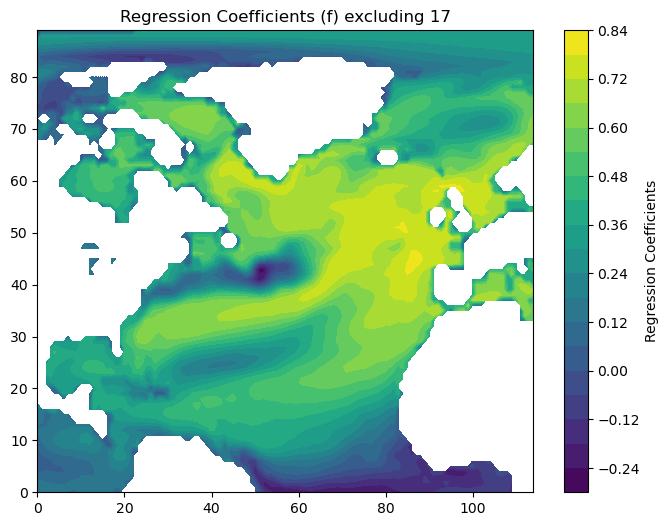

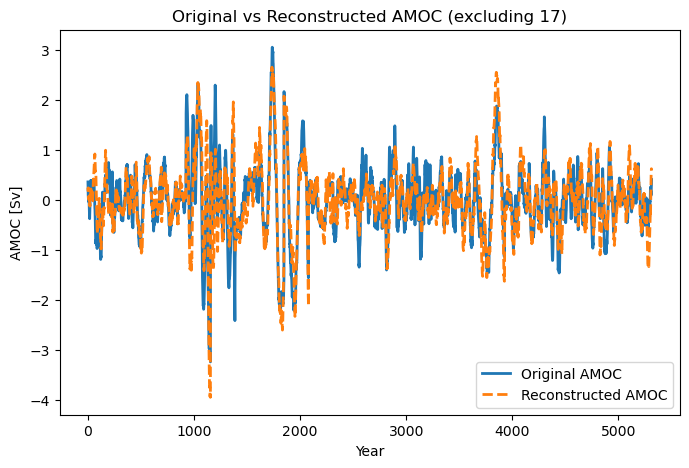

[17] f range: -0.2673 to 0.7939
[17] AMOC range: -3.2411 to 3.0513
[17] Reconstructed AMOC range: -3.9474 to 2.6522
Excluding model: 18
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/multimodel_excl_MPI-ESM1-2-HR_5313yrs.nc


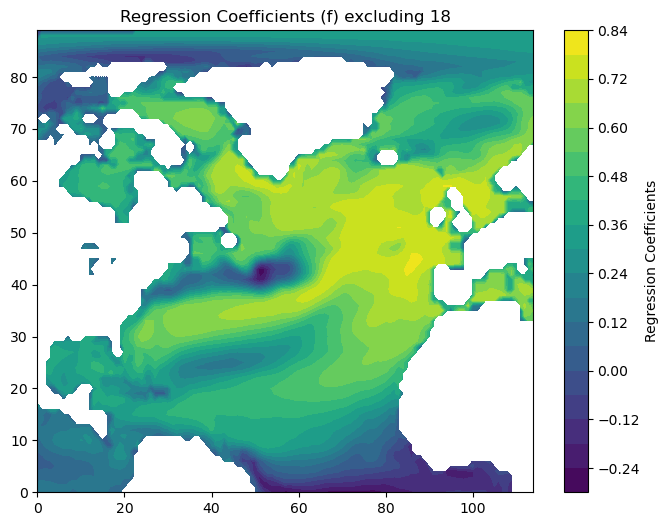

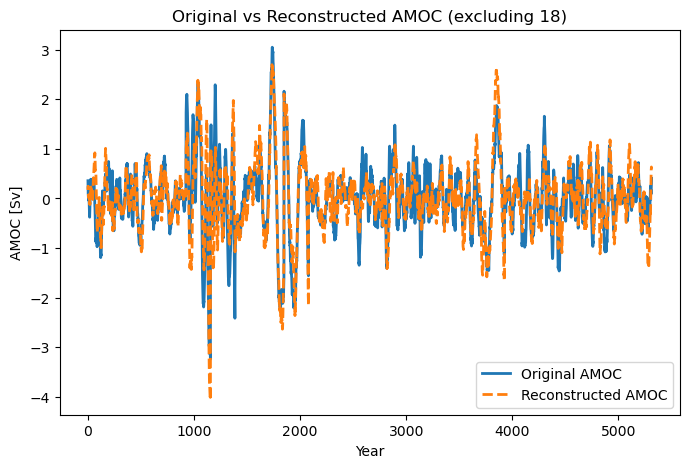

[18] f range: -0.2721 to 0.7929
[18] AMOC range: -3.2411 to 3.0513
[18] Reconstructed AMOC range: -4.0094 to 2.6989
Excluding model: 19
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/multimodel_excl_MPI-ESM1-2-LR_5313yrs.nc


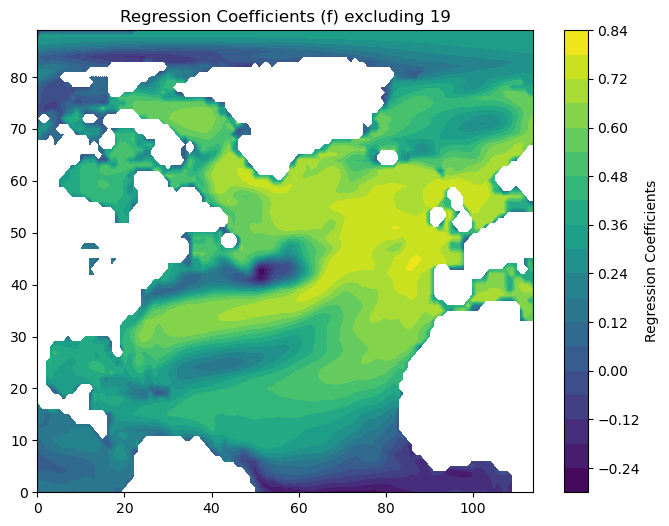

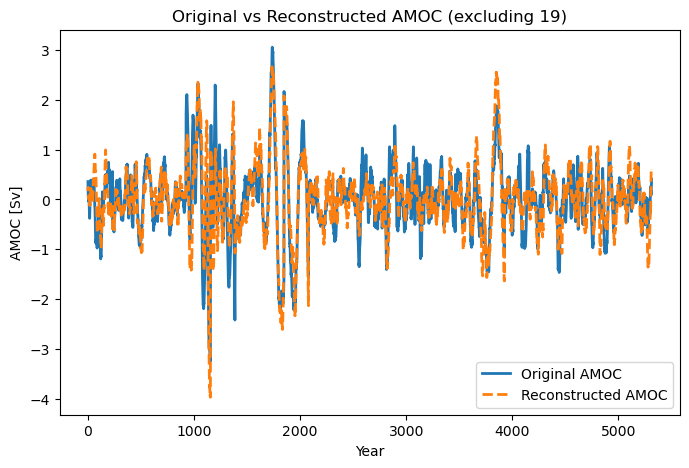

[19] f range: -0.2682 to 0.7890
[19] AMOC range: -3.2411 to 3.0513
[19] Reconstructed AMOC range: -3.9641 to 2.6595
Excluding model: 20
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/multimodel_excl_MRI-ESM2-0_5313yrs.nc


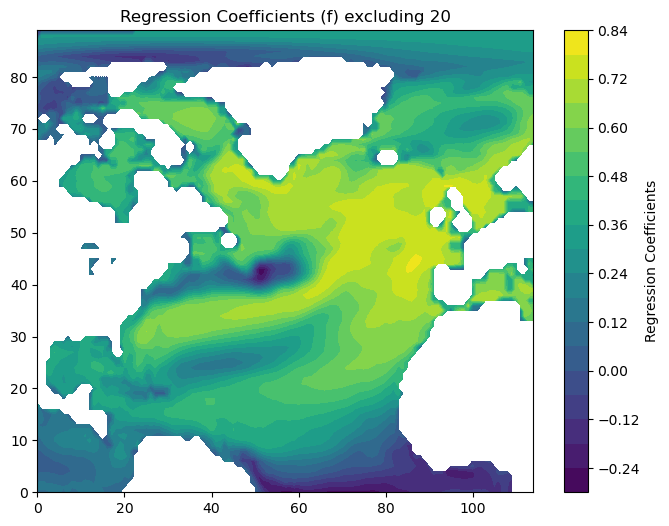

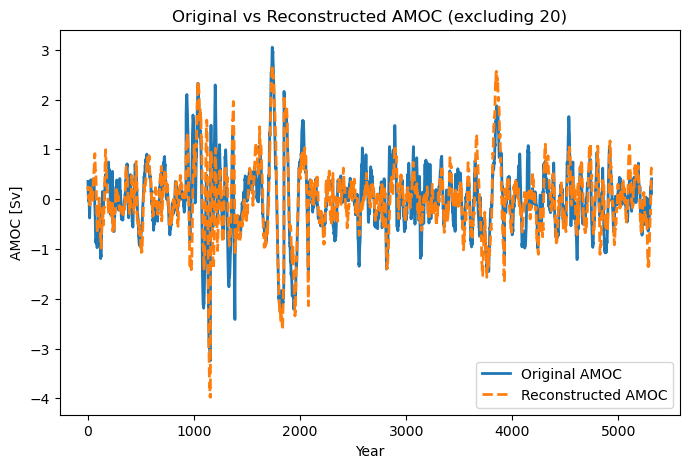

[20] f range: -0.2850 to 0.7903
[20] AMOC range: -3.2411 to 3.0513
[20] Reconstructed AMOC range: -3.9766 to 2.6751
Excluding model: 21
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/multimodel_excl_NorESM2-LM_5313yrs.nc


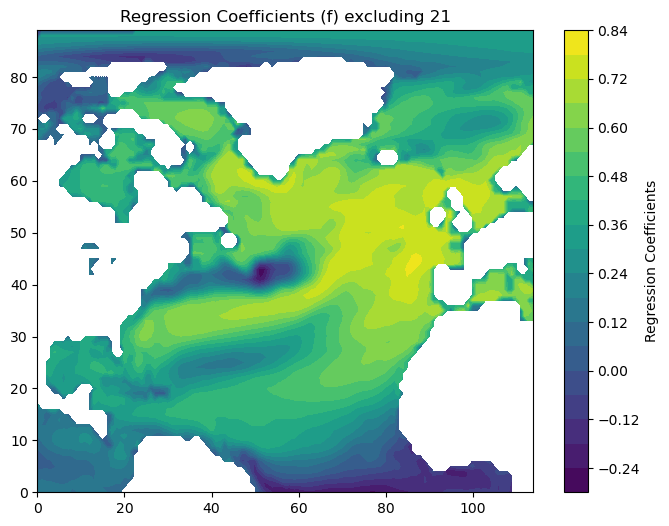

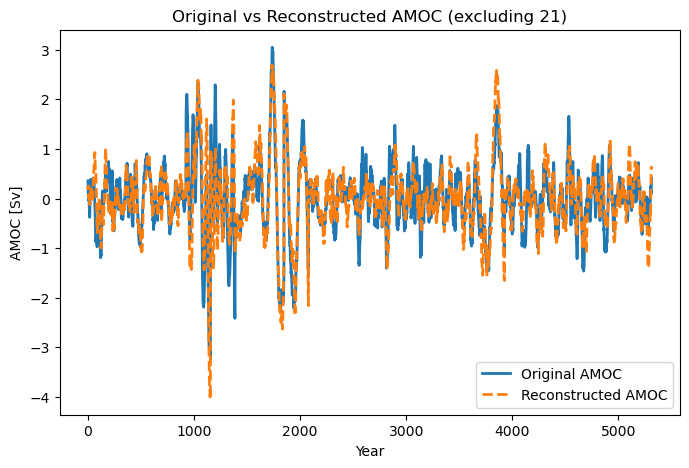

[21] f range: -0.2767 to 0.7913
[21] AMOC range: -3.2411 to 3.0513
[21] Reconstructed AMOC range: -4.0054 to 2.6927
Excluding model: 22
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/multimodel_excl_NorESM2-MM_5313yrs.nc


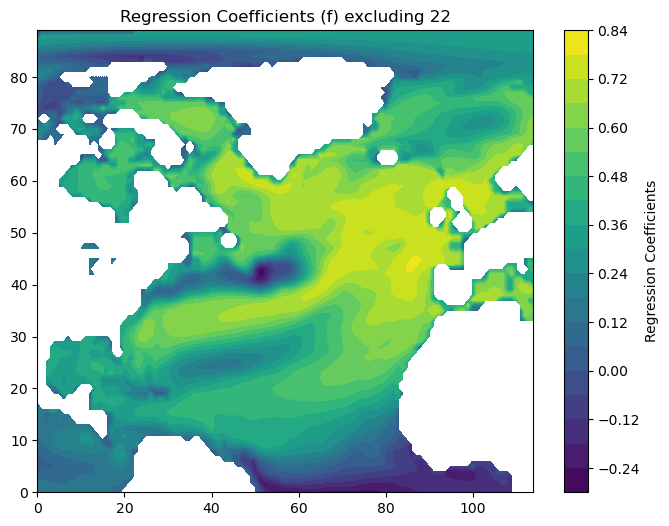

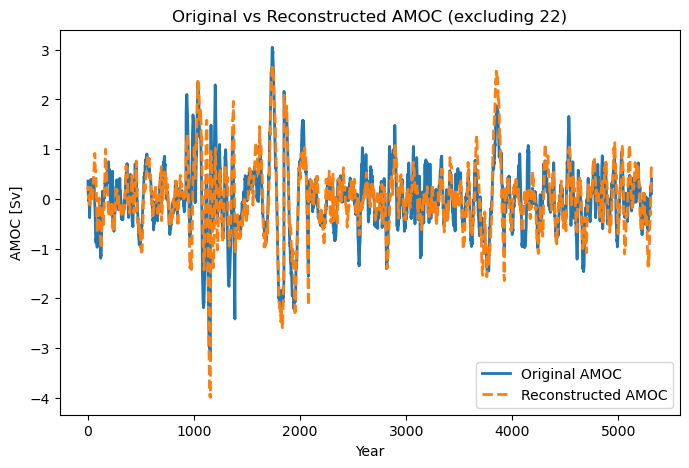

[22] f range: -0.2820 to 0.7903
[22] AMOC range: -3.2411 to 3.0513
[22] Reconstructed AMOC range: -3.9898 to 2.6728
Excluding model: 23
Saved to /glade/campaign/cgd/oce/people/rita/CMIP6/SST_AMOC_saved_regressions/multimodel_excl_UKESM1-0-LL_5313yrs.nc


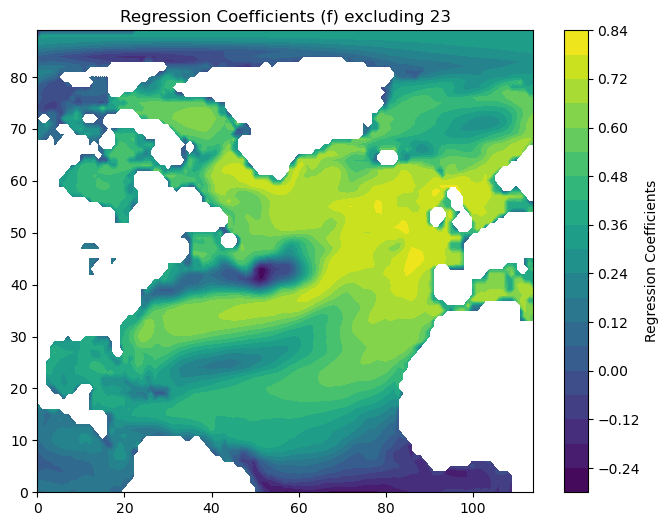

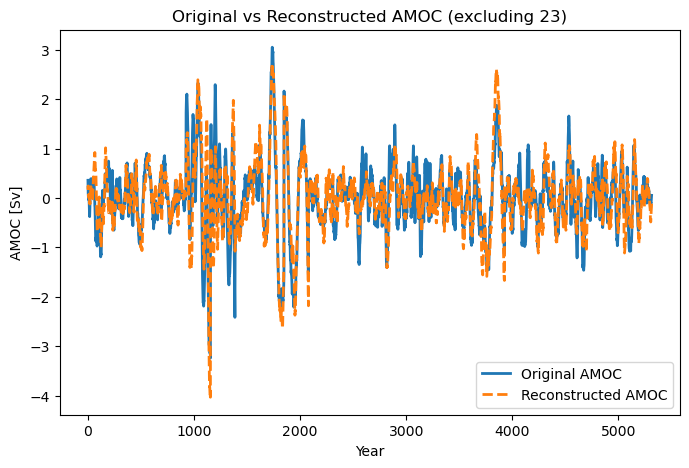

[23] f range: -0.2860 to 0.7959
[23] AMOC range: -3.2411 to 3.0513
[23] Reconstructed AMOC range: -4.0329 to 2.7011


In [43]:
for iex, excluded_model in enumerate(sst_multiple_models):
    excluded_model_name = model_names[iex]

    print(f"Excluding model: {excluded_model_name}")

    # Exclude the current model
    sst_matrices = [sst_multiple_models[key] for key in sst_multiple_models if key != excluded_model]
    amoc_matrices = [amoc_multiple_models[key] for key in amoc_multiple_models if key != excluded_model]

    # Stack SST and AMOC across remaining models
    sst_all = np.vstack(sst_matrices)
    amoc_all = np.hstack(amoc_matrices).T

    # Convert to xarray
    sst_all_da = xr.DataArray(
        sst_all,
        dims=["year", "lat", "lon"],
        coords={"year": np.arange(sst_all.shape[0]), "lat": sst.lat.values, "lon": sst.lon.values},
        name="sst"
    )

    amoc_all_da = xr.DataArray(
        amoc_all,
        dims=["year"],
        coords={"year": np.arange(amoc_all.shape[0])},
        name="amoc"
    )

    # Normalize
    sst_normalized = prepare_and_normalize_sst(sst_all_da)
    amoc, amoc_normalized, amoc_mean, amoc_std = prepare_and_normalize_amoc(amoc_all_da)

    # Train regression
    f, amoc_reconstructed = train_regression_and_reconstruct(sst_normalized, amoc_normalized, amoc_std)

    # Save outputs
    years = sst_all_da.year.values
    suffix = f"multimodel_excl_{excluded_model_name}"

    save_regression_map_sst_amoc_to_file(
        f, ny, nx, years, sst_smoothed, sst_normalized, amoc_normalized,
        amoc_std, amoc_reconstructed, suffix, PATH_saved_regressions,
        smoothing_period=running_mean_window
    )

    # Plot
    plot_regression_coefficients(f, ny, nx, f"Regression Coefficients (f) excluding {excluded_model}")
    plot_amoc_comparison(
        amoc, amoc_reconstructed, years,
        f"Original vs Reconstructed AMOC (excluding {excluded_model})",
        smoothing_period=running_mean_window
    )

    # Debug info
    print(f"[{excluded_model}] f range: {np.min(f):.4f} to {np.max(f):.4f}")
    print(f"[{excluded_model}] AMOC range: {np.min(amoc):.4f} to {np.max(amoc):.4f}")
    print(f"[{excluded_model}] Reconstructed AMOC range: {np.min(amoc_reconstructed):.4f} to {np.max(amoc_reconstructed):.4f}")


# Plot original AMOC vs. various reconstructions:
- Using this model's own regression pattern
- Using the full multi-model regression pattern
- Using multi-model regression patterns excluding one model at a time (to estimate reconstruction uncertainty)


ACCESS-CM2
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


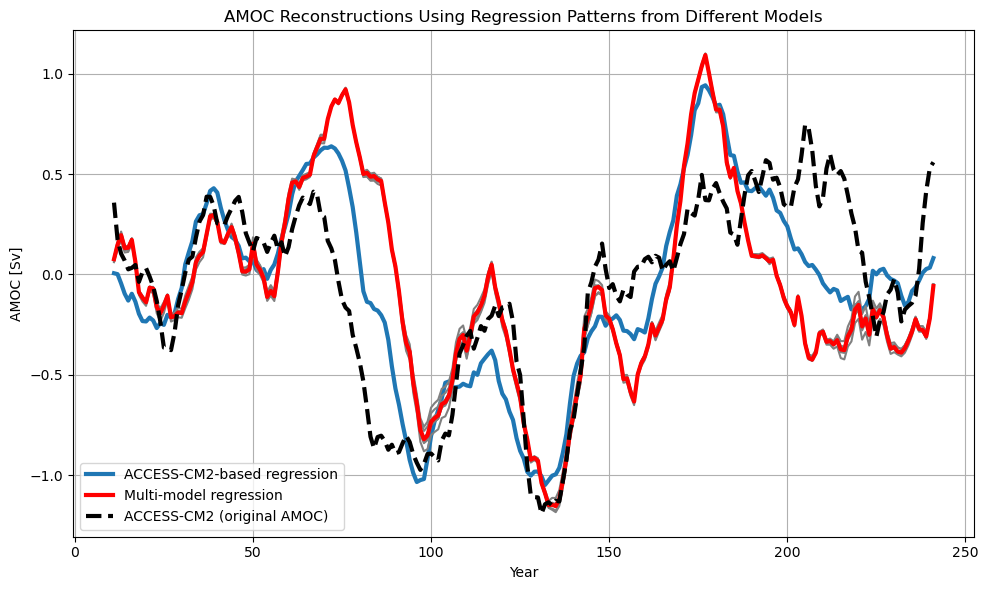

ACCESS-ESM1-5
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


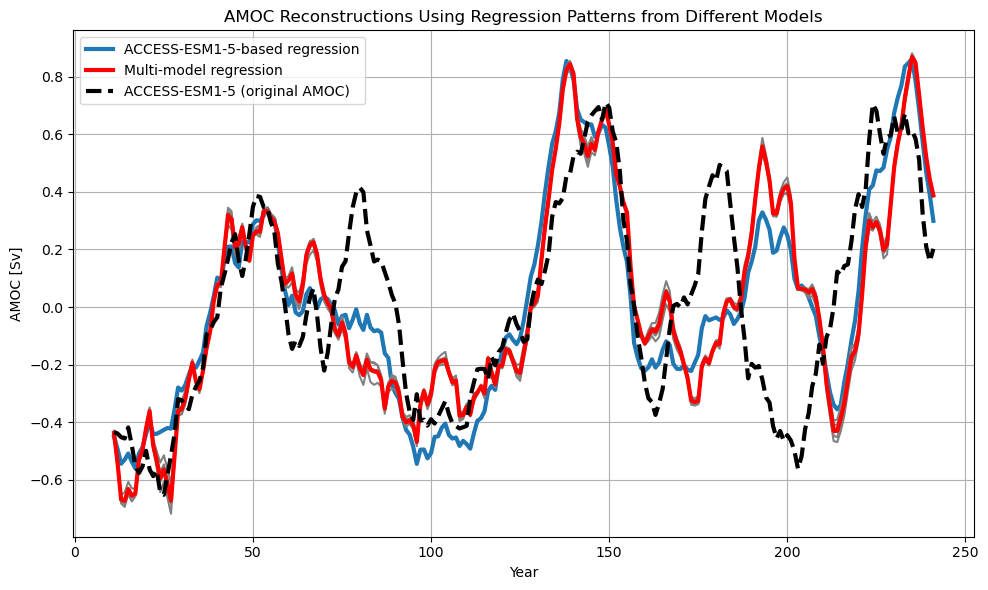

CESM2-WACCM
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


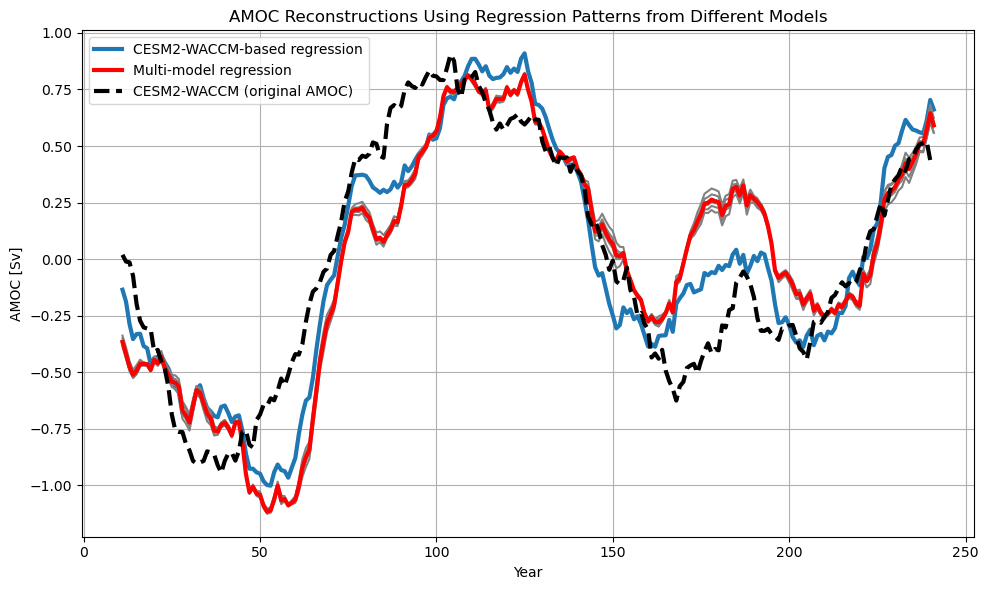

CESM2
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


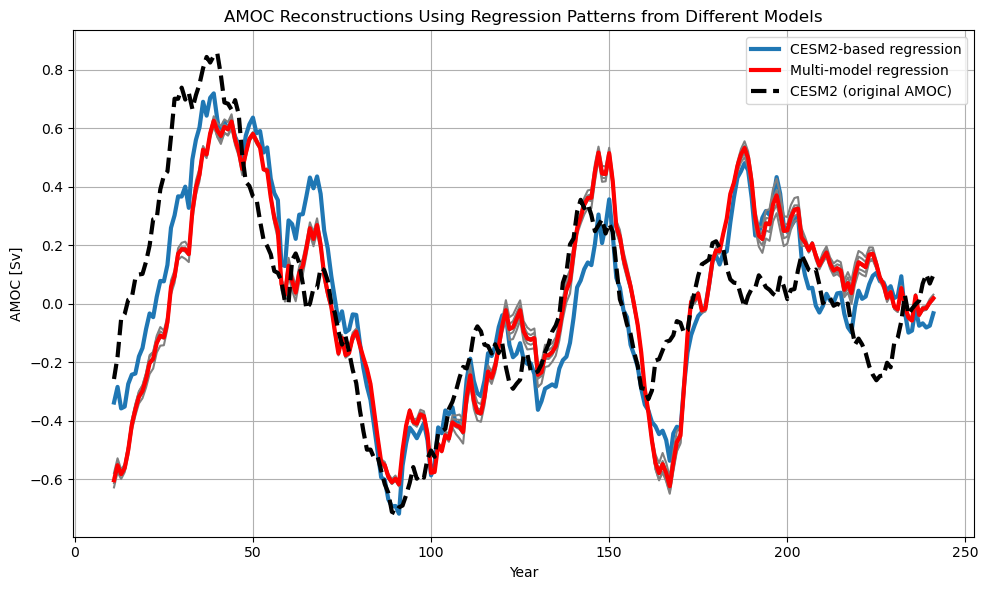

CMCC-CM2-SR5
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


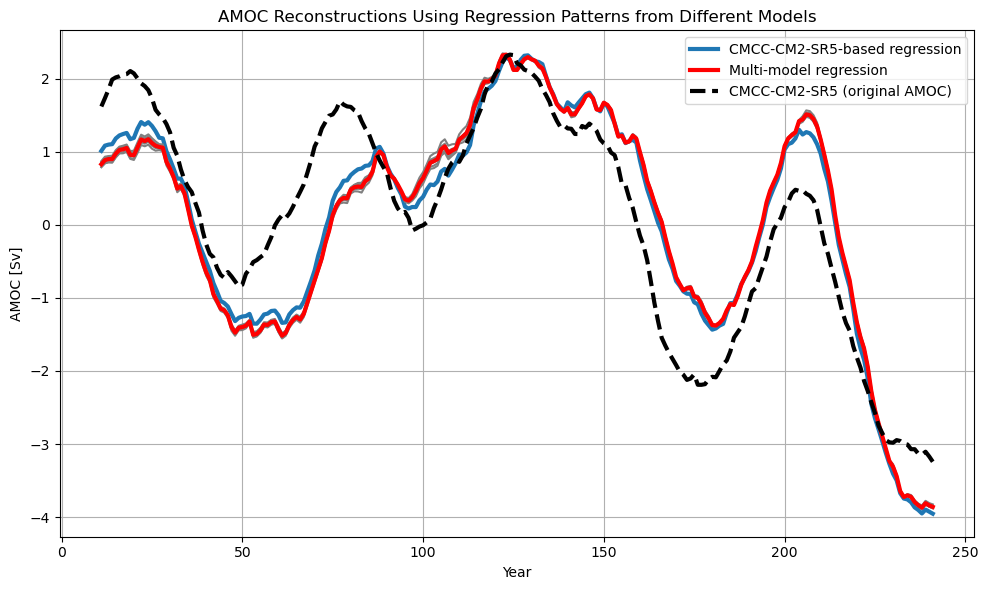

CMCC-ESM2
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


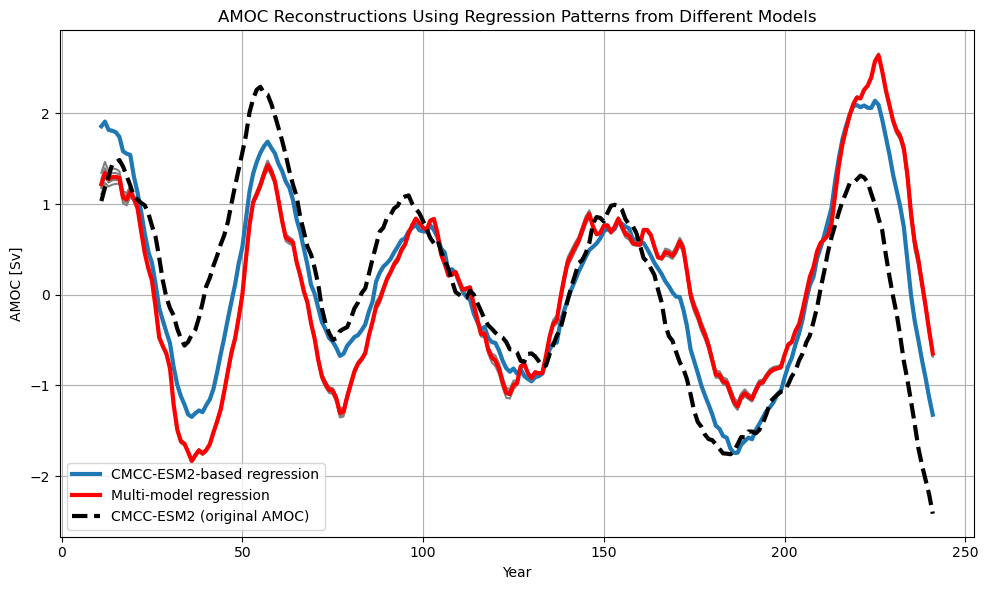

CNRM-CM6-1-HR
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


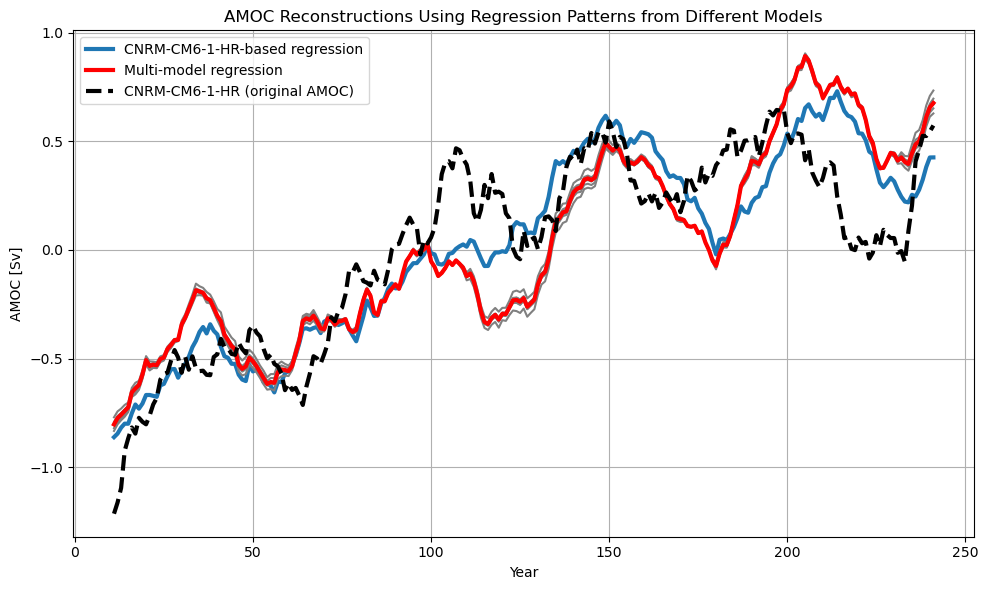

CNRM-CM6-1
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


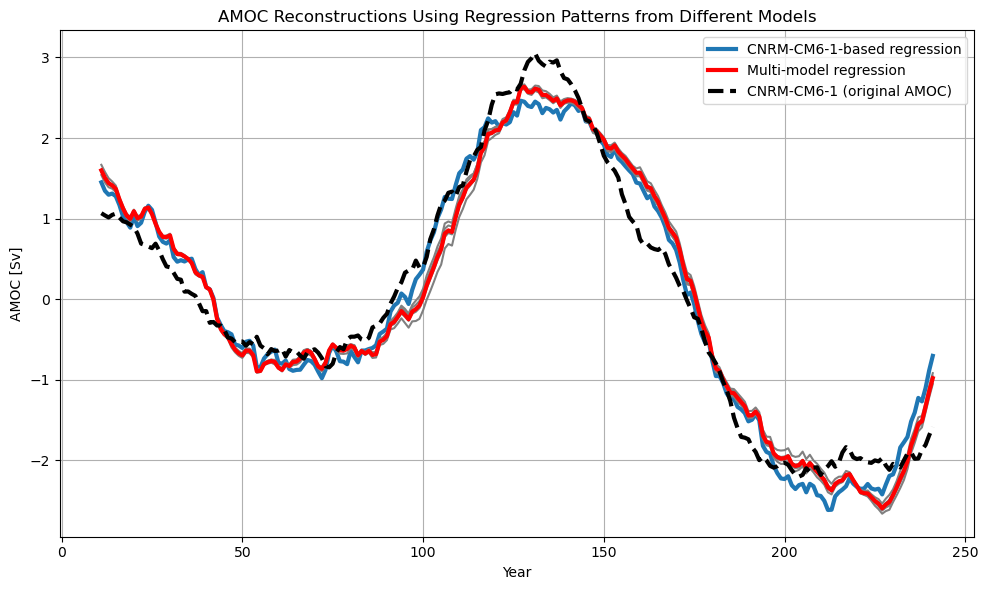

CNRM-ESM2-1
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


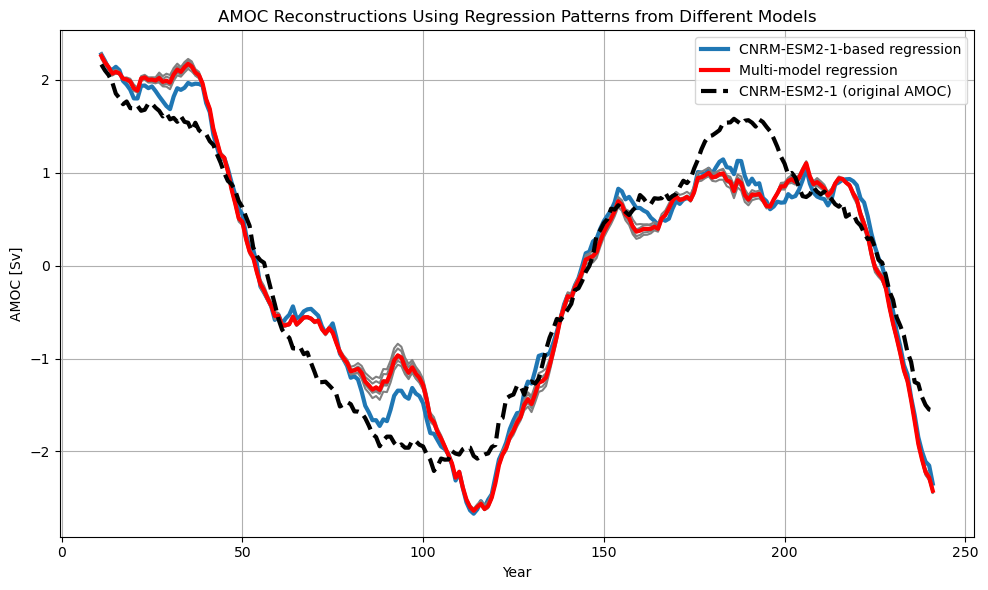

CanESM5-CanOE
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


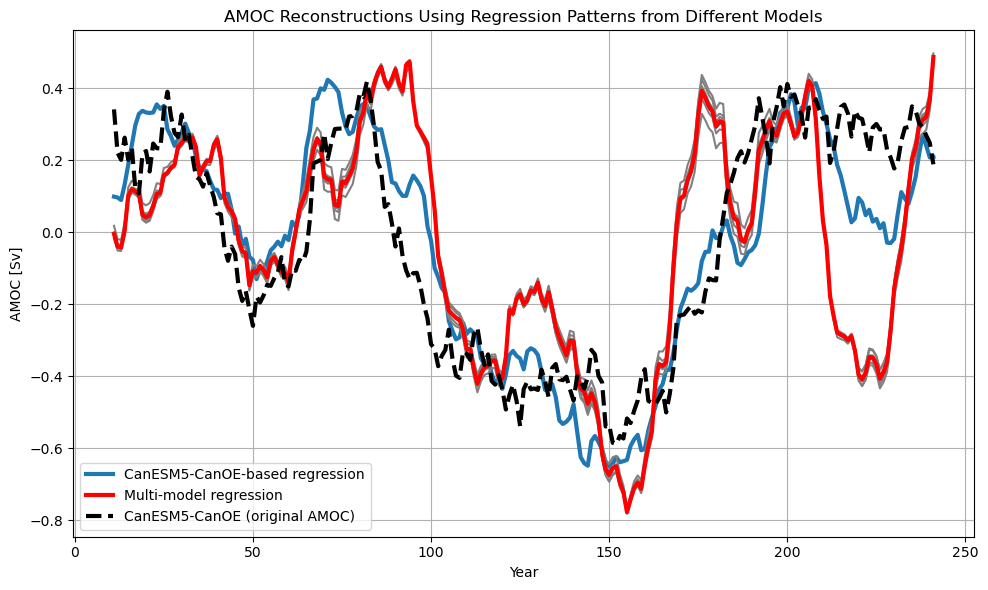

CanESM5
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


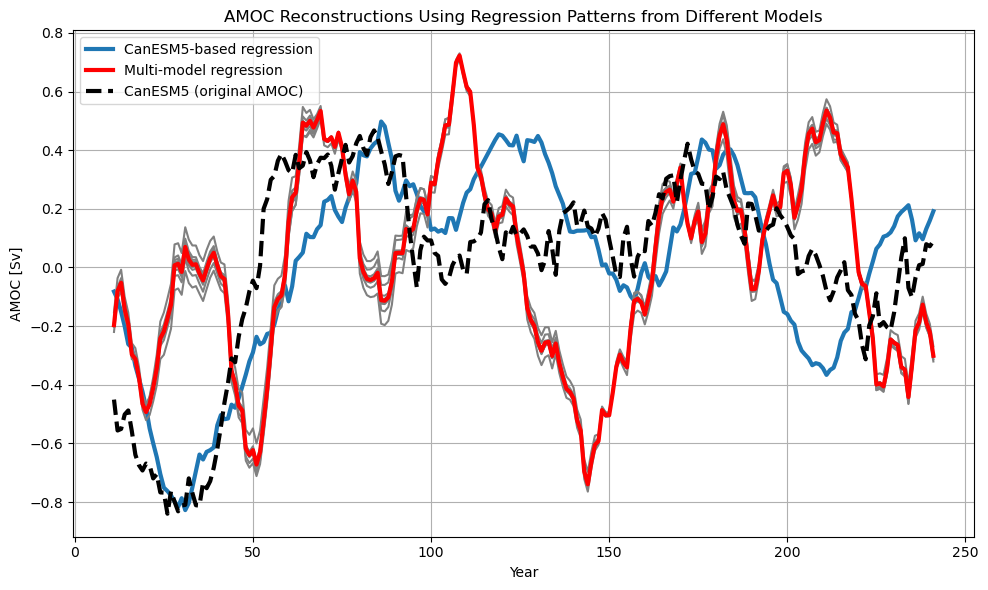

GFDL-CM4
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


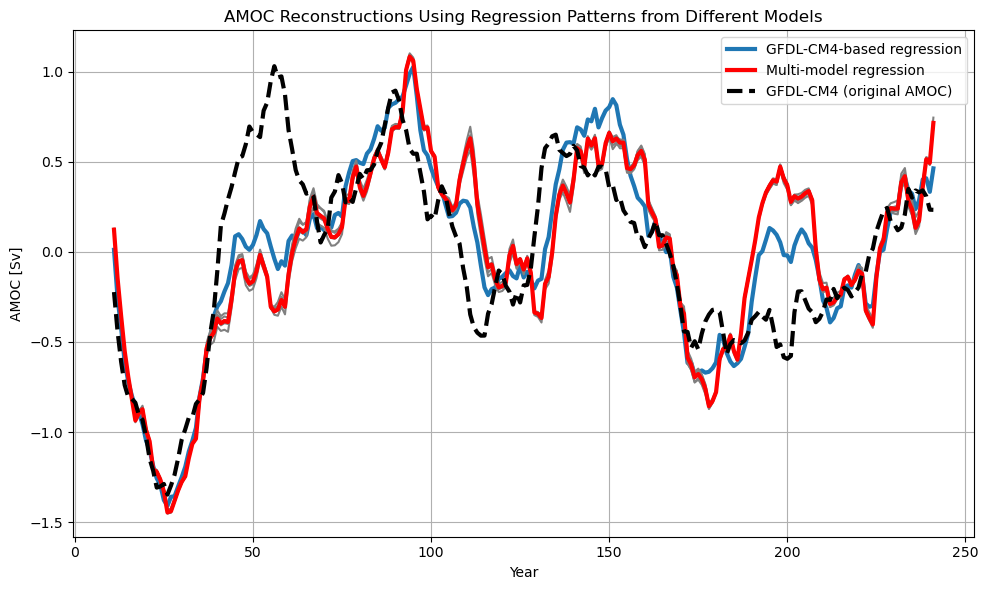

GFDL-ESM4
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


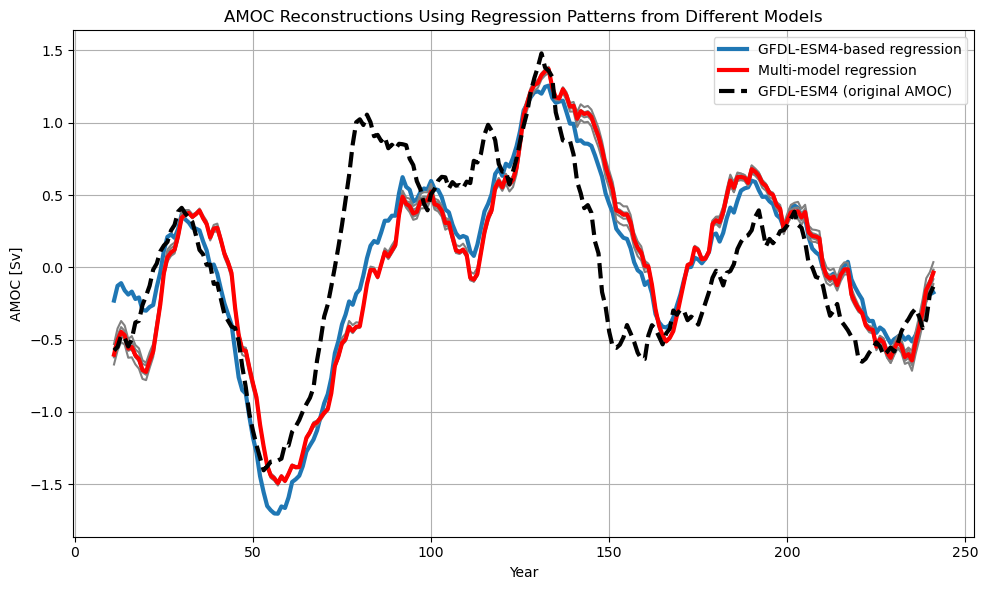

GISS-E2-1-G
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


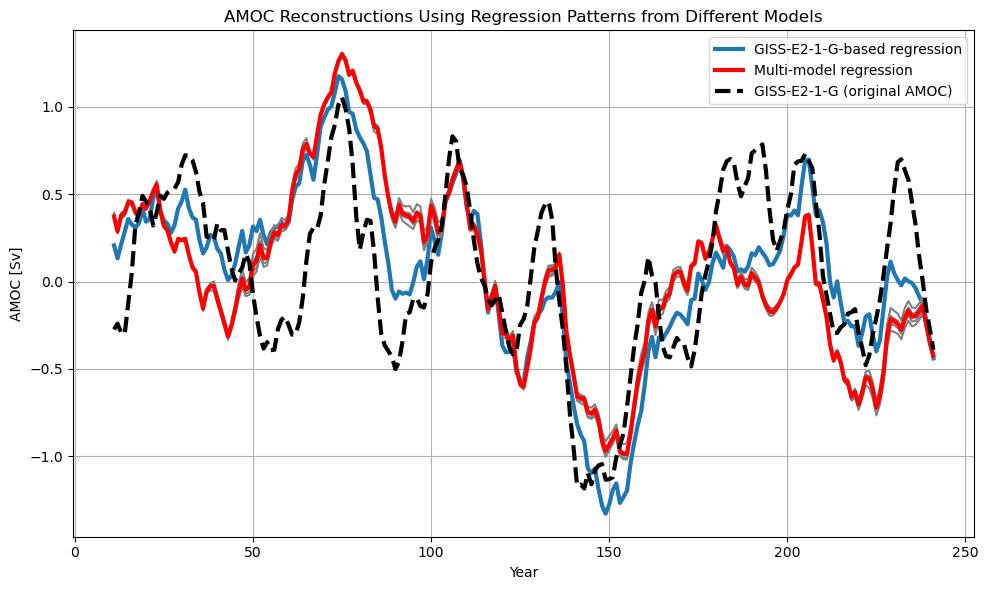

HadGEM3-GC31-LL
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


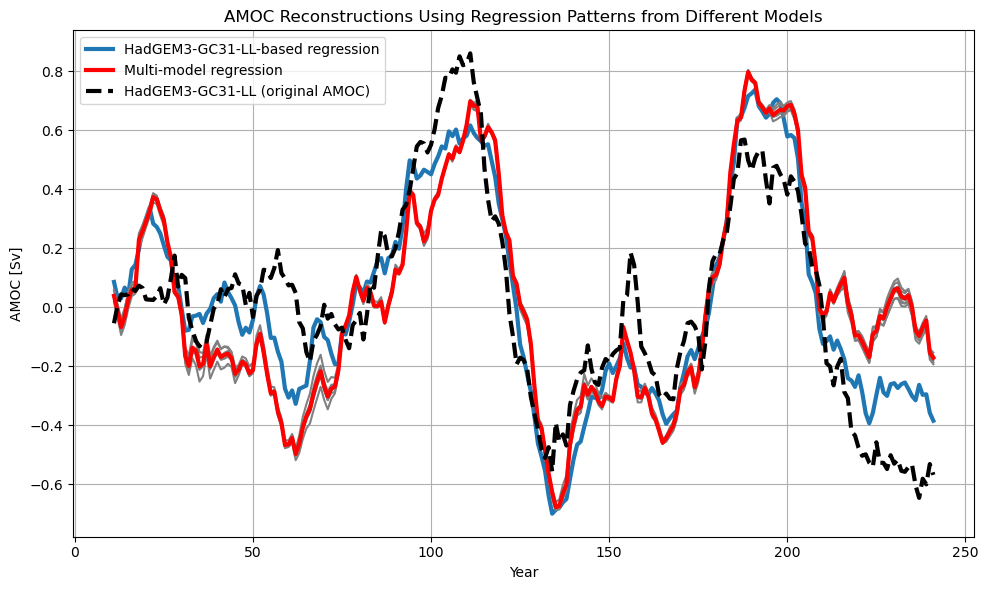

HadGEM3-GC31-MM
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


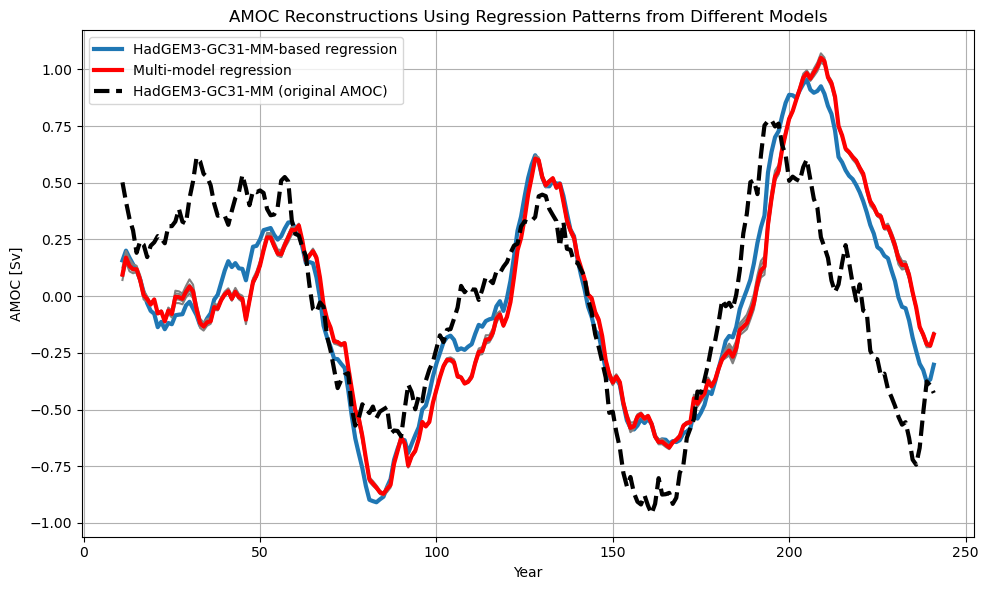

IPSL-CM6A-LR
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


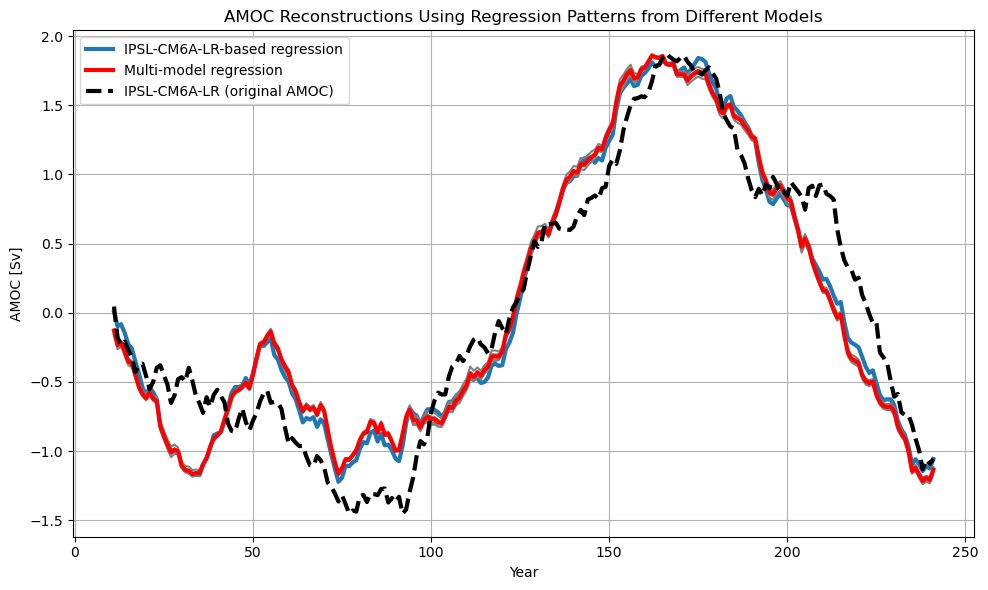

MIROC6
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


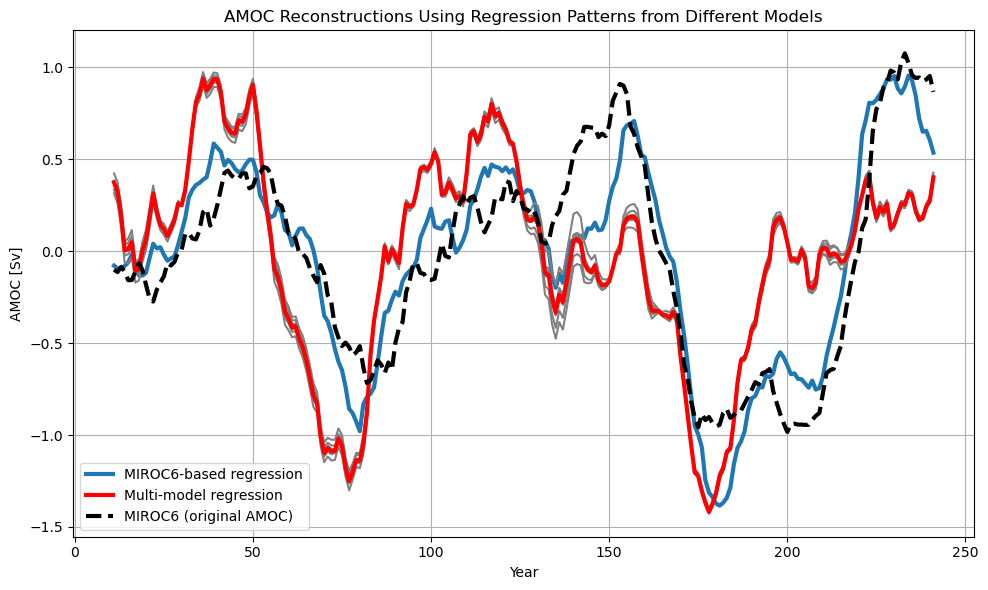

MPI-ESM1-2-HR
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


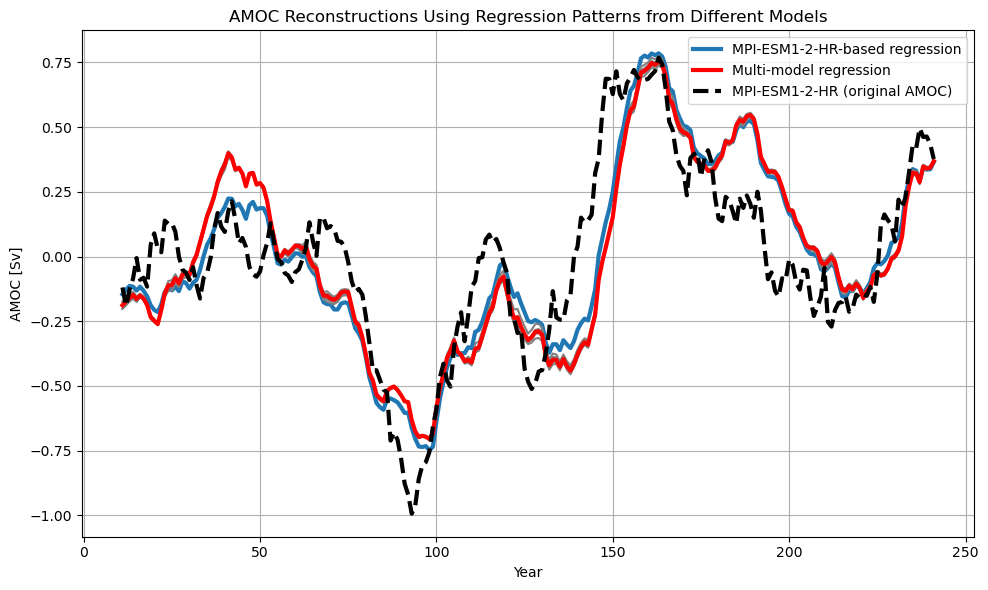

MPI-ESM1-2-LR
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


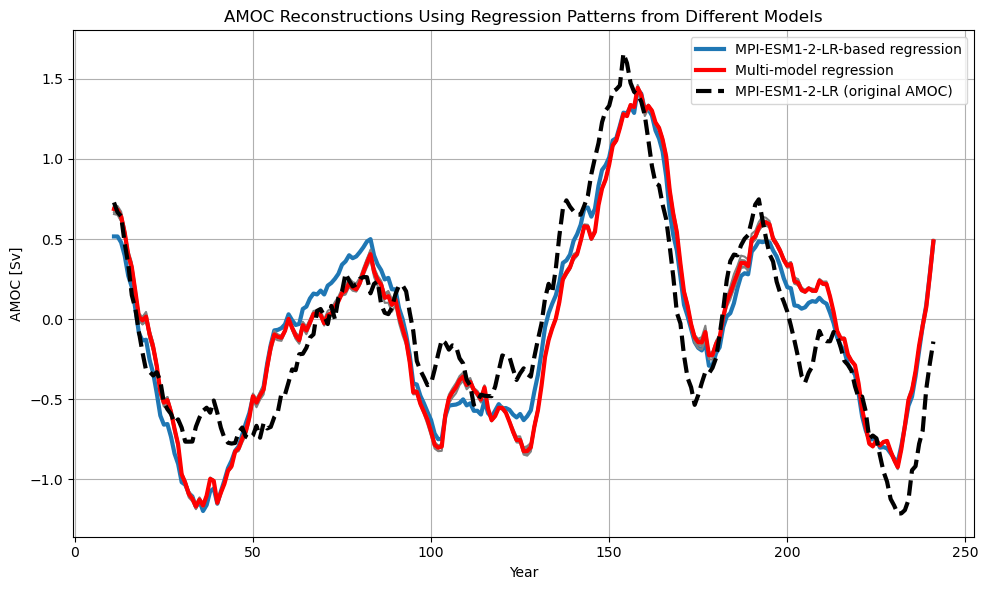

MRI-ESM2-0
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


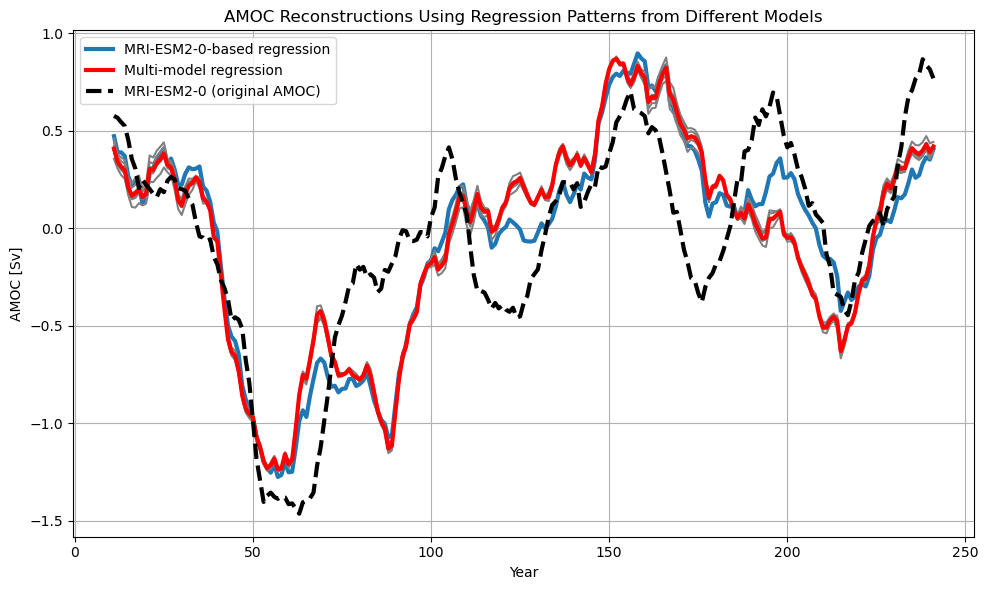

NorESM2-LM
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


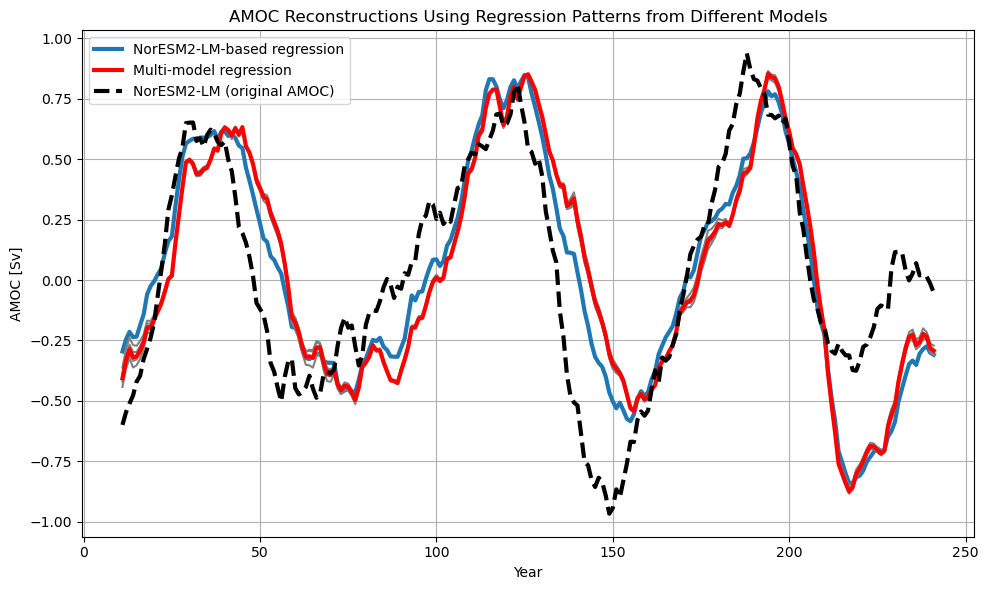

NorESM2-MM
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


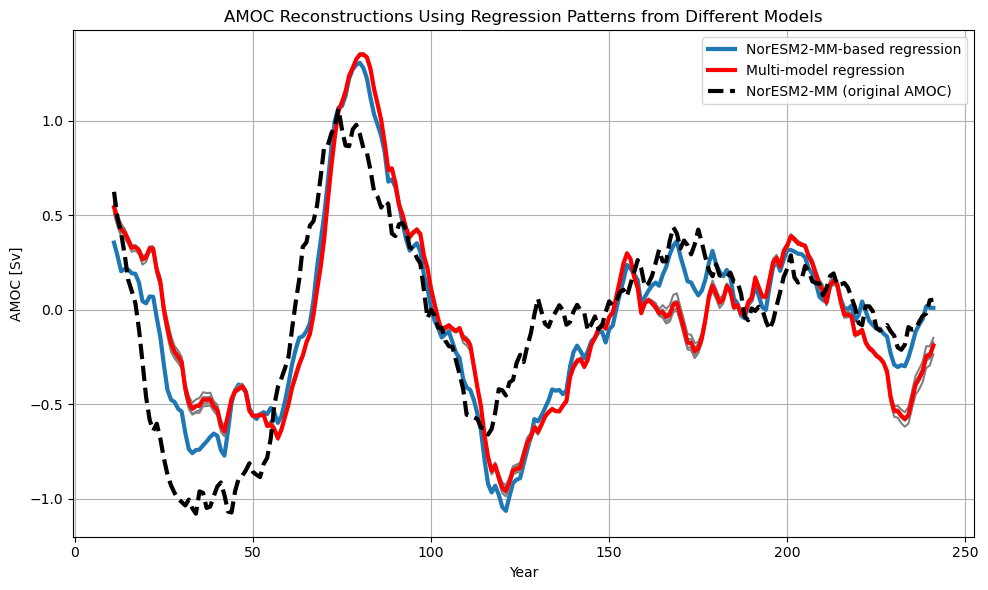

UKESM1-0-LL
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


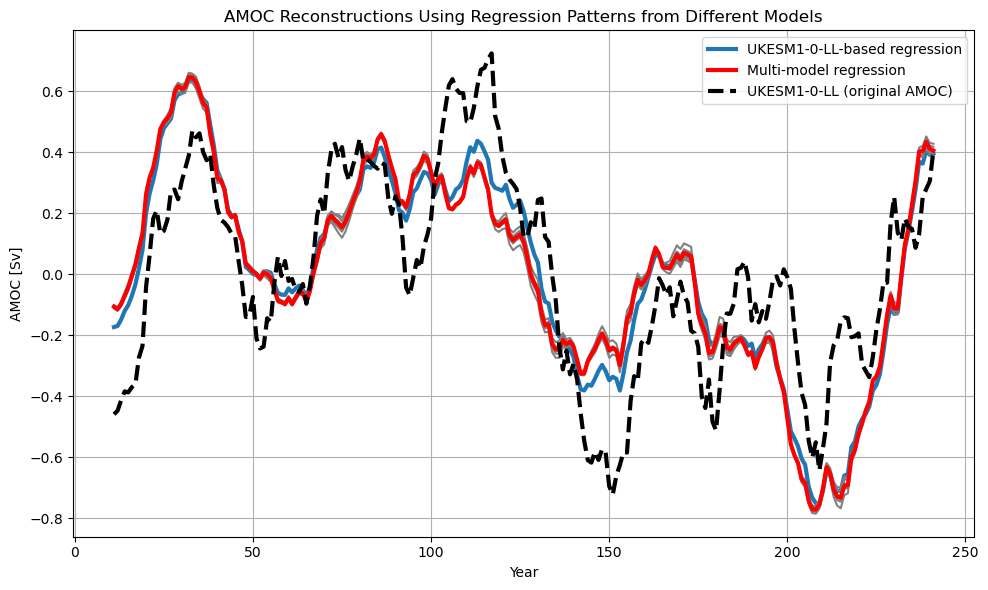

In [55]:
for i, model in enumerate(model_names):
    filename_amoc = PATH_AMOC + 'amoc_' + scenario + '_' + amoc_institution_names[i] + '_' + model + '_' + ens_members_appendices[i] + '.nc'
    filename_sst = PATH_SST + 'tos_Omon_' + model + '_' + scenario + '_' + ens_members_appendices[i] + '.nc'
    if os.path.exists(filename_amoc) and os.path.exists(filename_sst):

        print(model)
        
        sst_time_series = xr.open_dataset(filename_sst)['tos'].sel(lat = slice(lat_min, lat_max), lon = slice(lon_min, lon_max))
        sst_time_series['year'] = xr.DataArray(np.arange(1, len(sst_time_series['year'].values)+1), dims = 'year')
        sst_mean = sst_time_series.mean('year')
        sst_smoothed = (sst_time_series - sst_mean).rolling(year=running_mean_window, center=True).mean().dropna(dim='year', how='all')

        sst = sst_smoothed

        sst_normalized = prepare_and_normalize_sst(sst)

        # Get spatial grid dimensions for the North Atlantic region
        ny = sst.mean('year').shape[0]
        nx = sst.mean('year').shape[1]

        if model == 'IPSL-CM6A-LR':
            amoc_time_series = xr.open_dataset(filename_amoc)['amoc'].isel(year = slice(0, len(sst_time_series)), x = 0)
        else:
            amoc_time_series = xr.open_dataset(filename_amoc)['amoc'].isel(year = slice(0, len(sst_time_series)))
            
        amoc_mean = amoc_time_series.mean('year')
        amoc_smoothed = (amoc_time_series - amoc_mean).rolling(year=running_mean_window, center=True).mean().dropna(dim='year', how='all')
        amoc_smoothed['year'] = xr.DataArray(np.arange(1 + running_mean_window/2, 251 - running_mean_window/2 + 1), dims = 'year')

        amoc = amoc_smoothed

        # # Original AMOC
        # amoc_recon_with_regressions_from_different_models['Original AMOC'] = xr.DataArray(amoc,
        #                                                                                  dims=["year"],
        #                                                                                  coords={"year": np.arange(1 + running_mean_window/2, 251 - running_mean_window/2 + 1)},
        #                                                                                  name=model_regr)
        
        # Get spatial grid dimensions for the North Atlantic region
        ny = sst.mean('year').shape[0]
        nx = sst.mean('year').shape[1]


        # Prepare and normalize data    
        sst_normalized = prepare_and_normalize_sst(sst)
        amoc, amoc_normalized, amoc_mean, amoc_std = prepare_and_normalize_amoc(amoc)

        amoc_recon_with_regressions_from_different_models = xr.Dataset()


        # AMOC reconstructed using regression pattern from this same model 

        regression_pattern = xr.open_dataset(PATH_saved_regressions + model + '_231yrs.nc').fr.fillna(0).values.flatten()

        amoc_reconstructed = sst_normalized @ regression_pattern
        amoc_reconstructed = amoc_reconstructed * amoc_std / np.std(amoc_reconstructed) + amoc_mean
        amoc_recon_with_regressions_from_different_models[model] = xr.DataArray(amoc_reconstructed,
                                                                                         dims=["year"],
                                                                                         coords={"year": np.arange(1 + running_mean_window/2, 251 - running_mean_window/2 + 1)},
                                                                                         name=model_regr)
        
        # AMOC reconstructed using regression pattern from multi-model regression excluding one model at a time (to estimate reconstruction uncertainty)


        for imr, model_regr in enumerate(model_names):
            print(model_regr)
            regression_pattern = xr.open_dataset(PATH_saved_regressions + 'multimodel_excl_' + model_regr + '_5313yrs.nc').fr.fillna(0).values.flatten()

            amoc_reconstructed = sst_normalized @ regression_pattern
            amoc_reconstructed = amoc_reconstructed * amoc_std / np.std(amoc_reconstructed) + amoc_mean

            amoc_recon_with_regressions_from_different_models['excl_' + model_regr] = xr.DataArray(amoc_reconstructed,
                                                                                         dims=["year"],
                                                                                         coords={"year": np.arange(1 + running_mean_window/2, 251 - running_mean_window/2 + 1)},
                                                                                         name=model_regr)

        # AMOC reconstructed using regression pattern from multi-model regression

        regression_pattern = xr.open_dataset(PATH_saved_regressions + 'multimodel_5544yrs.nc').fr.fillna(0).values.flatten()
        amoc_reconstructed = sst_normalized @ regression_pattern
        amoc_reconstructed = amoc_reconstructed * amoc_std / np.std(amoc_reconstructed) + amoc_mean

        amoc_recon_with_regressions_from_different_models['multimodel'] = xr.DataArray(amoc_reconstructed,
                                                                                         dims=["year"],
                                                                                         coords={"year": np.arange(1 + running_mean_window/2, 251 - running_mean_window/2 + 1)},
                                                                                         name=model_regr)

        
        # amoc_recon_with_regressions_from_different_models.to_netcdf(PATH_saved_cross_regressions + '/SST_from_' + model + '_regression_patterns_from_all_models.nc')
        plt.figure(figsize=(10, 6))

        for model_regr in amoc_recon_with_regressions_from_different_models.data_vars:
            if model_regr == model:
                da = amoc_recon_with_regressions_from_different_models[model_regr]
                plt.plot(da["year"], da, label=model_regr +'-based regression', linewidth = 3)
            elif model_regr == 'multimodel':
                da = amoc_recon_with_regressions_from_different_models[model_regr]
                plt.plot(da["year"], da, label='Multi-model regression', linewidth = 3, c = 'r')
            else:
                da = amoc_recon_with_regressions_from_different_models[model_regr]
                plt.plot(da["year"], da, label='_nolegend_', c = 'grey')
                

        plt.plot(amoc_smoothed['year'], amoc_smoothed, label = model + ' (original AMOC)', color='black', linewidth=3, linestyle='--')
        

        plt.title("AMOC Reconstructions Using Regression Patterns from Different Models")
        plt.xlabel("Year")
        plt.ylabel("AMOC [Sv]")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()